# Axial Flux Motor Estimation Pipeline
## Method-led notebook for WLTP flux and resistance estimation

This notebook estimates PMSM electrical quantities from WLTP transient operating data and compares the estimated surfaces with the YASA GPR reference data. It is written as a transparent workflow rather than a black-box script: each stage explains what physical question is being answered, why a modelling decision is made, and how the result is implemented.

### Quantities estimated

| Quantity | Symbol | How this notebook estimates it |
|---|---|---|
| Stator resistance | $R_s$ | Regression of the q-axis voltage equation after filtering unstable transient windows |
| PM flux linkage | $\psi_{PM}(i_q)$ | WLTP GPR prediction of $\psi_d$ along the $i_d=0$ line |
| d-axis flux surface | $\psi_d(i_d,i_q)$ | 2-D Gaussian process regression over WLTP operating points |
| q-axis flux surface | $\psi_q(i_d,i_q)$ | 2-D Gaussian process regression over WLTP operating points |
| Iron-loss correction | $R_{fe}$ / $P_{fe}$ | Energy-balance residual after mechanical output and copper loss are removed |

The companion YASA characterisation notebook supplies the reference surfaces in:

```text
{PROJECT_DIR}/processed_v2/reference/psi_dq_1000rpm.csv
{PROJECT_DIR}/processed_v2/reference/psi_dq_6000rpm.csv
{PROJECT_DIR}/processed_v2/reference/psi_pm_iq.csv
{PROJECT_DIR}/processed_v2/reference/meta.json
```

This notebook also accepts the detailed YASA export directory:

```text
{PROJECT_DIR}/flux_pm_rs_gpr_outputs/csv
```

and automatically converts those files into the canonical `processed_v2/reference` schema.

### Figure order produced by `main()`

1. **Fig. 11** — transient-filter sensitivity, unchanged.  
2. **Linear/adaptive model error** — regression residuals, unchanged.  
3. **Fig. 12** — parameter relative uncertainty, unchanged.  
4. **Fig. 3** — WLTP $\psi_{PM}(i_q)$ estimate, unchanged.  
5. **Residual distribution** — $\psi_d$ and $\psi_q$ residual histograms, unchanged.  
6. **Fig. 5** — PM-flux comparison with only YASA 1000 rpm, YASA 2000 rpm, and `YASA $\psi_{PM}$ WLTP`.  
7. **PM-flux error figure** — WLTP estimate error against both YASA 1000 rpm and YASA 2000 rpm PM-flux curves.  
8. **Fig. 13** — GPR kernel evidence, unchanged.  
9. **Fig. 4a/4b** — resistance tracking and identifiability, unchanged.  
10. **Speed-dependent flux**, **speed-dependent resistance**, **isolated iron losses**, **equivalent iron-loss resistance**, and **$P_{elec}$**, unchanged.  
11. Final surface plots only: $\psi_d$ surfaces, $\psi_d$ error/uncertainty surfaces, $\psi_q$ surfaces, and $\psi_q$ error/uncertainty surfaces.

The old 2-D error heatmaps and legacy post-run comparison cells have been removed from the execution path.

### Resistance decision rule

The notebook prints a resistance-decision table. The highlighted row is the resistance value taken forward for the final WLTP flux surfaces. If the iron-loss-corrected verification succeeds, the corrected $R_s$ is used. If verification fails, the baseline adaptive-regression $R_s$ is used so the workflow still completes.

> This copy is configured to use `C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\final_est_pipelines` as the project folder.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

### Compatibility note

This notebook preserves the original speed-regime and power-balance resistance-estimation cells from `axial_flux_motor_pipeline_MODIFIED (1).ipynb`, while updating the PM-flux reference handling so both the current canonical columns (`psi_pm_Wb`, `psi_pm_2000rpm_Wb`) and the legacy `Rq_2000rpm` column are accepted.


---
## 1. Configuration — `config.py`

Central dataclass holding file paths, motor physics constants, and algorithm tuning parameters.  
All downstream modules reference this single config object.

In [2]:
from dataclasses import dataclass, field
from pathlib import Path
import numpy as np
import pandas as pd
import os
import json
from datetime import datetime

# Base project folder: the WLTP raw CSV and all YASA reference outputs should
# be placed somewhere under this directory.
PROJECT_DIR = Path(r"C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\final_est_pipelines")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

@dataclass
class PipelineConfig:
    """
    Central Configuration for the Axial Flux Motor Estimation Pipeline.

    This version is directory-compatible with the current reduced YASA GPR
    reference notebook. It accepts either:

        1. canonical axial-reference files in
           processed_v2/reference/

        2. detailed thesis export files in
           flux_pm_rs_gpr_outputs/csv/

    If detailed files are found, this config automatically writes compatible
    canonical copies to processed_v2/reference/ so the rest of the axial
    pipeline can use one stable schema.
    """

    # --- 1. FILE SETTINGS ---
    base_dir: Path = PROJECT_DIR
    input_filename: str = "p400s_wltp_raw.csv"

    # Canonical downstream reference directory. The companion YASA notebook now
    # writes these exact files here:
    #   psi_dq_1000rpm.csv
    #   psi_dq_6000rpm.csv
    #   psi_pm_iq.csv
    #   meta.json
    yasa_reference_dir: Path = PROJECT_DIR / "processed_v2" / "reference"

    # Which speed surface is the primary reference for psi_d, psi_q error metrics.
    reference_speed_tag: str = "1000rpm"     # "1000rpm" or "6000rpm"

    # --- 2. MOTOR PHYSICS CONSTANTS ---
    pole_pairs: int = 4
    alpha_cu: float = 0.00393
    alpha_pm: float = -0.0011
    t_ref: float = 20.0
    r_ref_guess: float = 0.045

    # --- 3. ALGORITHM TUNING PARAMETERS ---
    gamma: float = 5.0
    cond_thresh: float = 10.0
    didt_limit: float = 1500.0    # A/s, transient rejection threshold
    min_speed_rpm: float = 500.0
    min_current_a: float = 10.0

    # --- 4. CALCULATED PATHS ---
    results_dir: Path = field(init=False)

    def __post_init__(self):
        self.base_dir = Path(self.base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        os.chdir(self.base_dir)

        self.input_file = self.base_dir / self.input_filename

        # Build/refresh canonical reference copies where possible. This lets the
        # axial pipeline run whether the user points at the canonical reference
        # folder or the detailed CSV export folder from the YASA notebook.
        self.yasa_reference_dir = self._prepare_reference_directory()

        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        folder_name = f"{self.input_file.stem}_RUN_{timestamp}"
        self.results_dir = self.base_dir / folder_name
        os.makedirs(self.results_dir, exist_ok=True)

    @property
    def ref_dir(self) -> Path:
        """Back-compat alias for the YASA reference directory."""
        return self.yasa_reference_dir

    @property
    def rpm_to_rads(self) -> float:
        return 2 * np.pi / 60

    # ------------------------------------------------------------------
    # Reference-directory discovery and schema compatibility helpers
    # ------------------------------------------------------------------
    def _reference_dir_candidates(self):
        """Search locations used by the current and previous YASA notebooks."""
        candidates = [
            self.base_dir / "processed_v2" / "reference",          # canonical axial-compatible exports
            self.base_dir / "flux_pm_rs_gpr_outputs" / "csv",      # current detailed thesis exports
            self.base_dir / "flux_pm_rs_gpr_outputs" / "reference",
            self.base_dir / "flux_gpr_only_outputs" / "csv",       # earlier reduced notebook exports
            self.base_dir,
            Path(self.yasa_reference_dir),
        ]
        unique = []
        seen = set()
        for p in candidates:
            key = str(p)
            if key not in seen:
                unique.append(p)
                seen.add(key)
        return unique

    @staticmethod
    def _mtime(paths):
        paths = [Path(p) for p in paths if Path(p).exists()]
        return max((p.stat().st_mtime for p in paths), default=-1.0)

    @staticmethod
    def _rename_common_columns(df: pd.DataFrame) -> pd.DataFrame:
        """Normalise common id/iq and flux naming variants."""
        rename = {
            "Id": "id_A", "ID": "id_A", "id": "id_A", "i_d": "id_A", "idd": "id_A",
            "Iq": "iq_A", "IQ": "iq_A", "iq": "iq_A", "i_q": "iq_A", "iqq": "iq_A",
            "psi_d": "psi_d_Wb", "Psi_d": "psi_d_Wb", "psi_d_mean": "psi_d_Wb",
            "psi_q": "psi_q_Wb", "Psi_q": "psi_q_Wb", "psi_q_mean": "psi_q_Wb",
            "psi_d_std": "psi_d_sigma_Wb", "psi_d_sd": "psi_d_sigma_Wb",
            "psi_q_std": "psi_q_sigma_Wb", "psi_q_sd": "psi_q_sigma_Wb",
        }
        return df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    def _normalise_dq_dataframe(self, df: pd.DataFrame) -> pd.DataFrame:
        """Return a canonical psi_d/psi_q reference map dataframe."""
        df = self._rename_common_columns(df.copy())
        required = ["id_A", "iq_A", "psi_d_Wb", "psi_q_Wb"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"dq reference map is missing required columns: {missing}")
        if "psi_d_sigma_Wb" not in df.columns:
            df["psi_d_sigma_Wb"] = np.nan
        if "psi_q_sigma_Wb" not in df.columns:
            df["psi_q_sigma_Wb"] = np.nan
        return df[["id_A", "iq_A", "psi_d_Wb", "psi_q_Wb", "psi_d_sigma_Wb", "psi_q_sigma_Wb"]]

    def _normalise_single_surface(self, path: Path, axis: str) -> pd.DataFrame:
        """Read one split surface file and rename it as psi_d or psi_q."""
        df = self._rename_common_columns(pd.read_csv(path))
        if "iq_grid" in df.columns and "iq_A" not in df.columns:
            df = df.rename(columns={"iq_grid": "iq_A"})
        if "id_grid" in df.columns and "id_A" not in df.columns:
            df = df.rename(columns={"id_grid": "id_A"})

        value_candidates = [f"psi_{axis}_Wb", "psi_Wb", "y_mean", "mean", "z", "psi"]
        sigma_candidates = [f"psi_{axis}_sigma_Wb", "psi_sigma_Wb", "y_std", "std", "sd", "sigma"]
        value_col = next((c for c in value_candidates if c in df.columns), None)
        sigma_col = next((c for c in sigma_candidates if c in df.columns), None)
        if value_col is None:
            raise ValueError(f"{path.name} does not contain a recognised surface value column")
        out = df[["id_A", "iq_A", value_col]].copy()
        out = out.rename(columns={value_col: f"psi_{axis}_Wb"})
        if sigma_col is not None:
            out[f"psi_{axis}_sigma_Wb"] = df[sigma_col].values
        else:
            out[f"psi_{axis}_sigma_Wb"] = np.nan
        return out

    def _load_dq_reference_from_dir(self, folder: Path, speed_tag: str):
        """Load dq reference from one directory, accepting canonical/detailed/split names."""
        folder = Path(folder)
        direct_names = [
            f"psi_dq_{speed_tag}.csv",
            f"psi_dq_{speed_tag}_gpr_surface.csv",
        ]
        for name in direct_names:
            p = folder / name
            if p.exists():
                return self._normalise_dq_dataframe(pd.read_csv(p)), [p]

        # Split-surface fallback, as written by the detailed GPR export section.
        p_d = folder / f"fluxinductance{speed_tag}_psi_d_gpr_surface.csv"
        p_q = folder / f"fluxinductance{speed_tag}_psi_q_gpr_surface.csv"
        if p_d.exists() and p_q.exists():
            d = self._normalise_single_surface(p_d, "d")
            q = self._normalise_single_surface(p_q, "q")
            merged = pd.merge(d, q, on=["id_A", "iq_A"], how="inner")
            return self._normalise_dq_dataframe(merged), [p_d, p_q]

        return None, []

    def _select_newest_dq_reference(self, speed_tag: str):
        choices = []
        for folder in self._reference_dir_candidates():
            try:
                df, src_paths = self._load_dq_reference_from_dir(folder, speed_tag)
                if df is not None:
                    choices.append((self._mtime(src_paths), df, src_paths))
            except Exception as exc:
                print(f"    [Reference warning] Skipping {folder} for {speed_tag}: {exc}")
        if not choices:
            return None, []
        choices.sort(key=lambda x: x[0], reverse=True)
        return choices[0][1], choices[0][2]

    @staticmethod
    def _normalise_pm_dataframe(df: pd.DataFrame) -> pd.DataFrame:
        """
        Normalise PM-flux reference columns while keeping backward-compatible
        aliases used by the original axial-flux pipeline.

        Canonical columns written downstream:
            iq_grid
            psi_pm_Wb                    -> 1000 rpm primary PM-flux curve
            psi_pm_sigma_Wb
            psi_pm_2000rpm_Wb            -> 2000 rpm PM-flux curve, if available
            psi_pm_2000rpm_sigma_Wb

        Legacy aliases preserved/created:
            Rq_1000rpm                   -> psi_pm_Wb
            Rq_2000rpm                   -> psi_pm_2000rpm_Wb, or psi_pm_Wb fallback
            pm_reference_Wb              -> preferred PM reference for validation
        """
        df = df.copy()

        # Current-axis aliases
        if "iq_grid" not in df.columns and "iq_A" in df.columns:
            df = df.rename(columns={"iq_A": "iq_grid"})
        if "iq_grid" not in df.columns and "iq" in df.columns:
            df = df.rename(columns={"iq": "iq_grid"})

        # Legacy PM-flux aliases from the original notebook/reference files.
        if "Rq_1000rpm" in df.columns and "psi_pm_Wb" not in df.columns:
            df["psi_pm_Wb"] = df["Rq_1000rpm"]
        if "Rq_2000rpm" in df.columns and "psi_pm_2000rpm_Wb" not in df.columns:
            df["psi_pm_2000rpm_Wb"] = df["Rq_2000rpm"]

        # Current detailed combined export uses psi_pm_1000rpm_Wb as the primary curve.
        if "psi_pm_Wb" not in df.columns and "psi_pm_1000rpm_Wb" in df.columns:
            df["psi_pm_Wb"] = df["psi_pm_1000rpm_Wb"]
        if "psi_pm_sigma_Wb" not in df.columns and "psi_pm_1000rpm_sigma_Wb" in df.columns:
            df["psi_pm_sigma_Wb"] = df["psi_pm_1000rpm_sigma_Wb"]

        # Older combined weighted-average export names.
        if "psi_pm_Wb" not in df.columns and "wavg_1000rpm" in df.columns:
            df["psi_pm_Wb"] = df["wavg_1000rpm"]
        if "psi_pm_2000rpm_Wb" not in df.columns and "wavg_2000rpm" in df.columns:
            df["psi_pm_2000rpm_Wb"] = df["wavg_2000rpm"]

        # Last-resort behaviour: if only a 2000 rpm PM curve is present, use it
        # as the primary curve too so downstream validation can still run.
        if "psi_pm_Wb" not in df.columns and "psi_pm_2000rpm_Wb" in df.columns:
            df["psi_pm_Wb"] = df["psi_pm_2000rpm_Wb"]

        required = ["iq_grid", "psi_pm_Wb"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"PM reference curve is missing required columns: {missing}")

        if "psi_pm_sigma_Wb" not in df.columns:
            df["psi_pm_sigma_Wb"] = np.nan
        if "psi_pm_2000rpm_Wb" not in df.columns:
            df["psi_pm_2000rpm_Wb"] = np.nan
        if "psi_pm_2000rpm_sigma_Wb" not in df.columns:
            df["psi_pm_2000rpm_sigma_Wb"] = np.nan

        # Backward-compatible aliases expected by the original axial notebook.
        if "Rq_1000rpm" not in df.columns:
            df["Rq_1000rpm"] = df["psi_pm_Wb"]
        if "Rq_2000rpm" not in df.columns:
            if df["psi_pm_2000rpm_Wb"].notna().any():
                df["Rq_2000rpm"] = df["psi_pm_2000rpm_Wb"]
            else:
                df["Rq_2000rpm"] = df["psi_pm_Wb"]

        # Preferred PM reference for axial-pipeline error metrics. This keeps
        # the original 2000 rpm convention when that curve exists, while falling
        # back cleanly to the 1000 rpm primary curve when it does not.
        if df["Rq_2000rpm"].notna().any():
            df["pm_reference_Wb"] = df["Rq_2000rpm"]
            df["pm_reference_speed"] = "2000rpm"
        else:
            df["pm_reference_Wb"] = df["psi_pm_Wb"]
            df["pm_reference_speed"] = "1000rpm"

        return df[[
            "iq_grid",
            "psi_pm_Wb", "psi_pm_sigma_Wb",
            "psi_pm_2000rpm_Wb", "psi_pm_2000rpm_sigma_Wb",
            "Rq_1000rpm", "Rq_2000rpm",
            "pm_reference_Wb", "pm_reference_speed",
        ]]

    def _load_pm_reference_from_dir(self, folder: Path):
        """Load PM-flux reference from one directory, accepting current/legacy names."""
        folder = Path(folder)
        for name in ["psi_pm_iq.csv", "psi_pm_1000rpm_2000rpm_gpr_curves.csv"]:
            p = folder / name
            if p.exists():
                return self._normalise_pm_dataframe(pd.read_csv(p)), [p]

        # Separate-curve fallback.
        p1 = folder / "psi_pm_1000rpm_gpr_curve.csv"
        p2 = folder / "psi_pm_2000rpm_gpr_curve.csv"
        if p1.exists():
            df1 = pd.read_csv(p1)
            df1 = df1.rename(columns={"iq_A": "iq_grid"}) if "iq_A" in df1.columns else df1
            out = pd.DataFrame({
                "iq_grid": df1["iq_grid"].values,
                "psi_pm_Wb": df1["psi_pm_Wb"].values,
                "psi_pm_sigma_Wb": df1["psi_pm_sigma_Wb"].values if "psi_pm_sigma_Wb" in df1.columns else np.nan,
            })
            src = [p1]
            if p2.exists():
                df2 = pd.read_csv(p2)
                df2 = df2.rename(columns={"iq_A": "iq_grid"}) if "iq_A" in df2.columns else df2
                out["psi_pm_2000rpm_Wb"] = np.interp(out["iq_grid"], df2["iq_grid"], df2["psi_pm_Wb"])
                if "psi_pm_sigma_Wb" in df2.columns:
                    out["psi_pm_2000rpm_sigma_Wb"] = np.interp(out["iq_grid"], df2["iq_grid"], df2["psi_pm_sigma_Wb"])
                src.append(p2)
            return self._normalise_pm_dataframe(out), src

        return None, []

    def _select_newest_pm_reference(self):
        choices = []
        for folder in self._reference_dir_candidates():
            try:
                df, src_paths = self._load_pm_reference_from_dir(folder)
                if df is not None:
                    choices.append((self._mtime(src_paths), df, src_paths))
            except Exception as exc:
                print(f"    [Reference warning] Skipping {folder} for psi_pm: {exc}")
        if not choices:
            return None, []
        choices.sort(key=lambda x: x[0], reverse=True)
        return choices[0][1], choices[0][2]

    def _prepare_reference_directory(self) -> Path:
        """Create/refresh processed_v2/reference with canonical files when possible."""
        canonical_dir = self.base_dir / "processed_v2" / "reference"
        canonical_dir.mkdir(parents=True, exist_ok=True)

        reference_sources = {}
        for speed_tag in ["1000rpm", "6000rpm"]:
            df, src_paths = self._select_newest_dq_reference(speed_tag)
            if df is not None:
                out = canonical_dir / f"psi_dq_{speed_tag}.csv"
                df.to_csv(out, index=False)
                reference_sources[f"psi_dq_{speed_tag}"] = [str(p) for p in src_paths]

        pm_df, pm_src = self._select_newest_pm_reference()
        if pm_df is not None:
            out = canonical_dir / "psi_pm_iq.csv"
            pm_df.to_csv(out, index=False)
            reference_sources["psi_pm_iq"] = [str(p) for p in pm_src]

        meta_path = canonical_dir / "meta.json"
        meta = {
            "reference_dir": str(canonical_dir),
            "reference_schema": "axial_flux_motor_pipeline_final_est_pipelines",
            "reference_speed_tag_default": self.reference_speed_tag,
            "source_files": reference_sources,
            "created_by": "PipelineConfig._prepare_reference_directory",
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)

        active_map = canonical_dir / f"psi_dq_{self.reference_speed_tag}.csv"
        active_pm = canonical_dir / "psi_pm_iq.csv"
        if not active_map.exists() or not active_pm.exists():
            print("    [Reference warning] Canonical reference files are incomplete.")
            print(f"    Expected active map: {active_map}")
            print(f"    Expected PM file:    {active_pm}")
            print("    Search directories checked:")
            for p in self._reference_dir_candidates():
                print(f"      - {p}")
        return canonical_dir

    def get_reference_files(self):
        """Return absolute paths to canonical YASA-GPR reference files."""
        tag = self.reference_speed_tag
        return {
            "map_file_1000rpm": self.yasa_reference_dir / "psi_dq_1000rpm.csv",
            "map_file_6000rpm": self.yasa_reference_dir / "psi_dq_6000rpm.csv",
            "map_file":          self.yasa_reference_dir / f"psi_dq_{tag}.csv",
            "pm_file":           self.yasa_reference_dir / "psi_pm_iq.csv",
            "meta_file":         self.yasa_reference_dir / "meta.json",
        }


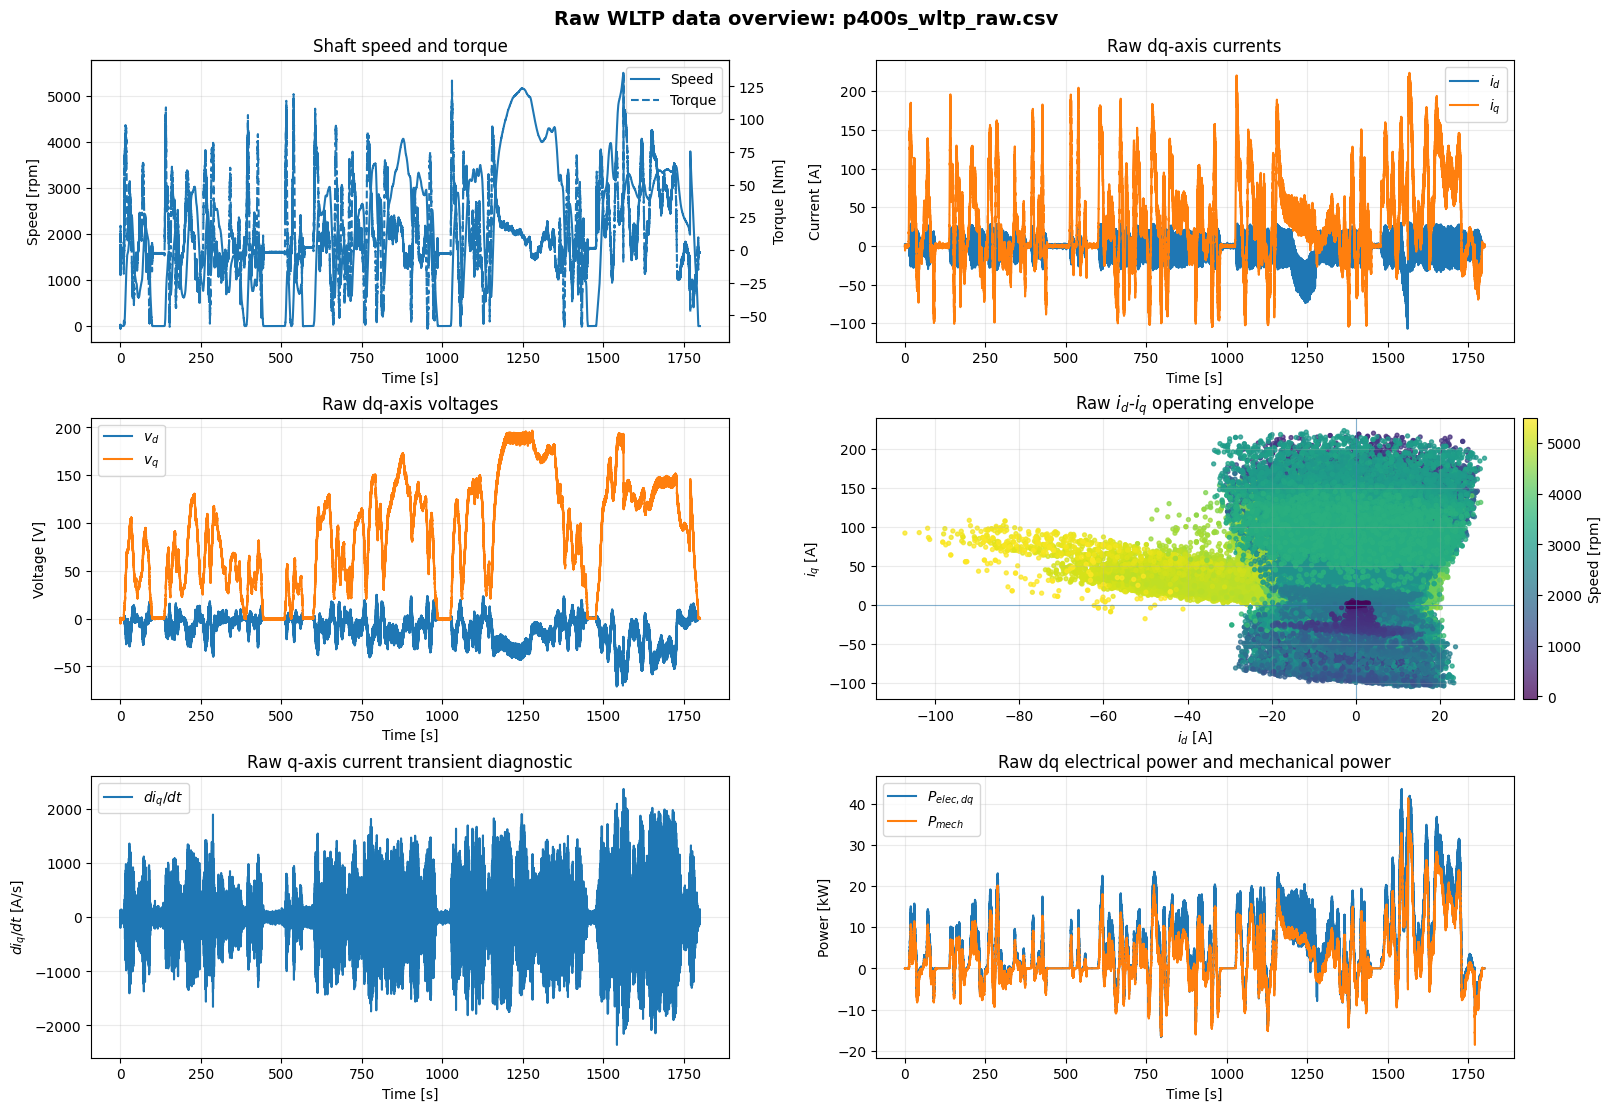

In [3]:
# --- Raw WLTP data overview plot: drop-in cell for the beginning of the notebook ---

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve raw data path.
if "cfg" in globals():
    raw_path = Path(cfg.input_file)
elif "PROJECT_DIR" in globals():
    raw_path = Path(PROJECT_DIR) / "p400s_wltp_raw.csv"
else:
    raw_path = Path("p400s_wltp_raw.csv")

if not raw_path.exists():
    raise FileNotFoundError(f"Raw data file not found: {raw_path}")

# The WLTP CSV used by the estimator contains two metadata/unit rows after the header.
df_raw = pd.read_csv(raw_path, header=0, skiprows=[1, 2])

def first_existing(df, candidates):
    """Return the first available column name from a candidate list."""
    return next((c for c in candidates if c in df.columns), None)

def as_numeric(series):
    return pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)

# Column discovery, aligned with the pipeline conventions.
time_col = first_existing(df_raw, ["recorder_time", "time_s", "time", "Time"])
speed_col = first_existing(df_raw, ["SPEED", "speed_rpm", "Speed", "shaft_speed_rpm"])
torque_col = first_existing(df_raw, ["T_Act_Shaft", "TORQUE", "torque_Nm", "Torque"])

id_col = first_existing(df_raw, ["CAN_Inverter1_I_Id", "Id", "id_A", "Id_raw"])
iq_col = first_existing(df_raw, ["CAN_Inverter1_I_Iq", "Iq", "iq_A", "Iq_raw"])
vd_col = first_existing(df_raw, ["CAN_Inverter1_U_12", "Vd", "ud_V", "Vd_raw"])
vq_col = first_existing(df_raw, ["CAN_Inverter1_U_23", "Vq", "uq_V", "Vq_raw"])

temp_col = first_existing(df_raw, [
    "T_Motor", "T_Motor1", "MotorTemp", "motor_temp_C",
    "CAN_Motor_Temp", "CAN_Inverter1_Temp"
])

required = {
    "speed": speed_col,
    "id": id_col,
    "iq": iq_col,
    "vd": vd_col,
    "vq": vq_col,
}
missing = [name for name, col in required.items() if col is None]
if missing:
    raise KeyError(
        f"Missing required raw-data columns for: {missing}\n"
        f"Available columns are:\n{list(df_raw.columns)}"
    )

# Time vector.
if time_col is not None:
    t_raw = as_numeric(df_raw[time_col])
    t = t_raw - np.nanmin(t_raw)
    dt_med = np.nanmedian(np.diff(t[np.isfinite(t)]))
    if np.isfinite(dt_med) and dt_med > 0.5:
        t = t / 1000.0
else:
    t = np.arange(len(df_raw)) / 100.0

speed = as_numeric(df_raw[speed_col])
Id = as_numeric(df_raw[id_col])
Iq = as_numeric(df_raw[iq_col])
Vd = as_numeric(df_raw[vd_col])
Vq = as_numeric(df_raw[vq_col])

torque = as_numeric(df_raw[torque_col]) if torque_col is not None else None
temp = as_numeric(df_raw[temp_col]) if temp_col is not None else None

# Derived diagnostics.
omega_m = speed * 2.0 * np.pi / 60.0
P_elec_kW = 1.5 * (Vd * Id + Vq * Iq) / 1000.0
P_mech_kW = torque * omega_m / 1000.0 if torque is not None else None

diq_dt = np.gradient(Iq, t)
didt_limit = cfg.didt_limit if "cfg" in globals() and hasattr(cfg, "didt_limit") else None

# Plot.
fig, axes = plt.subplots(3, 2, figsize=(16, 11), constrained_layout=True)
fig.suptitle(f"Raw WLTP data overview: {raw_path.name}", fontsize=14, fontweight="bold")

# 1. Speed and torque.
ax = axes[0, 0]
ax.plot(t, speed, label="Speed")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Speed [rpm]")
ax.grid(True, alpha=0.25)

if torque is not None:
    ax2 = ax.twinx()
    ax2.plot(t, torque, linestyle="--", label="Torque")
    ax2.set_ylabel("Torque [Nm]")
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
else:
    ax.legend(loc="best")

ax.set_title("Shaft speed and torque")

# 2. dq currents.
ax = axes[0, 1]
ax.plot(t, Id, label=r"$i_d$")
ax.plot(t, Iq, label=r"$i_q$")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Current [A]")
ax.set_title("Raw dq-axis currents")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

# 3. dq voltages.
ax = axes[1, 0]
ax.plot(t, Vd, label=r"$v_d$")
ax.plot(t, Vq, label=r"$v_q$")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Raw dq-axis voltages")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

# 4. Operating envelope.
ax = axes[1, 1]
valid_map = np.isfinite(Id) & np.isfinite(Iq) & np.isfinite(speed)
sc = ax.scatter(Id[valid_map], Iq[valid_map], c=speed[valid_map], s=8, alpha=0.75)
cb = fig.colorbar(sc, ax=ax, pad=0.015)
cb.set_label("Speed [rpm]")
ax.axhline(0, linewidth=0.8, alpha=0.5)
ax.axvline(0, linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$i_d$ [A]")
ax.set_ylabel(r"$i_q$ [A]")
ax.set_title(r"Raw $i_d$-$i_q$ operating envelope")
ax.grid(True, alpha=0.25)

# 5. Transient diagnostic.
ax = axes[2, 0]
ax.plot(t, diq_dt, label=r"$di_q/dt$")
if didt_limit is not None:
    ax.axhline(didt_limit, linestyle="--", linewidth=1.0, label="Filter limit")
    ax.axhline(-didt_limit, linestyle="--", linewidth=1.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"$di_q/dt$ [A/s]")
ax.set_title("Raw q-axis current transient diagnostic")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

# 6. Power balance if torque is available; otherwise plot temperature if available.
ax = axes[2, 1]
if P_mech_kW is not None:
    ax.plot(t, P_elec_kW, label=r"$P_{elec,dq}$")
    ax.plot(t, P_mech_kW, label=r"$P_{mech}$")
    ax.set_ylabel("Power [kW]")
    ax.set_title("Raw dq electrical power and mechanical power")
    ax.legend(loc="best")
elif temp is not None:
    ax.plot(t, temp, label="Motor temperature")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title("Raw motor temperature")
    ax.legend(loc="best")
else:
    ax.text(
        0.5, 0.5,
        "No torque or temperature column found",
        ha="center", va="center",
        transform=ax.transAxes
    )
    ax.set_title("Optional raw diagnostic unavailable")

ax.set_xlabel("Time [s]")
ax.grid(True, alpha=0.25)

plt.show()

---
## 2. Motor Physics Estimator — `motor_physics.py`

The core estimation engine. Contains:
- **Phase 1:** Data loading & calibration (CAN → physics vectors)
- **Phase 2:** Structure-adaptive linear regression (R, Ψ, Ld, Verr)
- **Phase 3:** Bayesian flux mapping via Gaussian Process Regression
- **Phase 4:** Reference LUT validation
- **Phase 5:** Sensitivity & kernel sweeps, thermal tracking
- **Phase 9:** Iron loss correction (applied on second pass)

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel, Matern
from sklearn.metrics import mean_squared_error
import warnings
import scipy.stats as stats
# Ensure this import matches your file structure

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

class MotorPhysicsEstimator:
    """
    The 'Brain' of the operation.
    Updated to include Gaussian Process Regression (Pathway 3) for Flux Mapping.
    """
    
    def __init__(self, config):
        self.cfg = config
        
        # State variables to store trained models
        self.poly = None
        self.flux_model_d = None
        self.flux_model_q = None
        
        # Training data bounds (for validating reference maps later)
        self.train_bounds = {}
        
        # Gaussian Process Models
        self.gp_d = None
        self.gp_q = None
        self.scaler_X = None

    def load_and_calibrate(self):
        """
        Phase 1: Load CSV and convert CAN units to Physics Vectors.
        FIX: Now applies di/dt filter to remove high-transient data from training.
        """
        # Load Data
        df = pd.read_csv(self.cfg.input_file, header=0, skiprows=[1, 2])

        # 1. Calculate Electrical Speed (rad/s)
        df['omega_e'] = df['SPEED'] * self.cfg.rpm_to_rads * self.cfg.pole_pairs
        
        # 2. Map Columns to Physics Vectors
        df['Vq'] = df['CAN_Inverter1_U_23']
        df['Vd'] = df['CAN_Inverter1_U_12']
        df['Iq'] = df['CAN_Inverter1_I_Iq']
        df['Id'] = df['CAN_Inverter1_I_Id']
        
        # --- CRITICAL CHANGE: DISABLE AUTOMATIC CORRECTION ---
        # We comment this out so Phase 1 loads RAW data for diagnosis.
        # The correction is applied manually in Phase 9 (Verification) 
        # by calling load_and_calibrate again AFTER Phase 8 exists.
        
        if (self.cfg.results_dir / 'DATA_Energy_Balance.csv').exists():
             # Uncomment the print below if you want to know when it happens
             # print("    [Info] Energy Balance data detected. Applying Iron Loss Correction...")
             # Note: We rely on the caller (main script) to decide if this should run, 
             # but keeping it automatic if file exists is the standard "Verify" behavior.
             # However, for Phase 1 (Diagnosis), we want RAW data.
             # Ideally, we add a flag, but relying on file existence + phase order is sufficient
             # IF we delete the file at start, OR we just apply it here:
             
             # Actually, for the "Verification Phase" to work without arguments, 
             # we DO need this here. But it messes up Phase 1 if re-running.
             # SAFE FIX: Only apply if we are NOT in the initial setup. 
             # But for simplicity in your script, we will apply it if the file exists.
             # IMPORTANT: You must DELETE 'DATA_Energy_Balance.csv' if you want a fresh "Diagnosis".
             df = self.apply_iron_loss_correction(df)
        # -----------------------------------------------------

        # --- MANDATORY PRE-PROCESSING ---
        # Check for Phase 8 data early. Applying this here ensures Phase 2 and 3 
        # use "Magnetizing Current" rather than "Terminal Current".
        if (self.cfg.results_dir / 'DATA_Energy_Balance.csv').exists():
             df = self.apply_iron_loss_correction(df)

        # --- NEW: Calculate Transients (di/dt) ---
        # Convert ms to seconds
        df['time_s'] = (df['recorder_time'] - df['recorder_time'].iloc[0]) / 1000.0
        
        # Calculate derivative of Iq w.r.t time
        df['diq_dt'] = np.gradient(df['Iq'], df['time_s'])
        
        # --- DEBUGGING BLOCK (Diagnosis) ---
        # Inspect the distribution of the calculated derivative and time step
        avg_dt = df['time_s'].diff().mean()
        max_transient = df['diq_dt'].abs().max()
        p99_transient = np.percentile(df['diq_dt'].abs(), 99)
        
        print(f"    [Debug] Time Step Analysis:")
        print(f"            Avg dt: {avg_dt:.6f} s (Freq: {1/avg_dt:.1f} Hz)")
        print(f"    [Debug] Derivative (di/dt) Analysis:")
        print(f"            Max Found: {max_transient:.4f} A/s")
        print(f"            99th Pctl: {p99_transient:.4f} A/s")
        print(f"            Filter Limit: {self.cfg.didt_limit} A/s")
        
        if max_transient < 10.0 and self.cfg.didt_limit > 100:
             print("    [WARNING] Transients are suspiciously low. Check 'recorder_time' units (ms vs s).")
        # -----------------------------------
        
        # 3. Create Filtering Masks
        # Fit Mask: High speed AND Low Transient (Stable)
        mask_fit = (
            (df['SPEED'] > self.cfg.min_speed_rpm) & 
            (np.abs(df['diq_dt']) < self.cfg.didt_limit)  
        )
        
        # Verify it worked by printing the count
        df_train = df[mask_fit].copy()
        
        # Print debug info to confirm it worked
        print(f"    [Filter] Raw Data: {len(df)} -> High Speed: {sum(df['SPEED'] > self.cfg.min_speed_rpm)} -> Stable (di/dt<{self.cfg.didt_limit}): {len(df_train)}")
        
        # Save bounds for later use in validation
        self.train_bounds = {
            'id_min': df_train['Id'].min(), 'id_max': df_train['Id'].max(),
            'iq_min': df_train['Iq'].min(), 'iq_max': df_train['Iq'].max()
        }
        
        return df_train, df

    def fit_adaptive_model(self, df_train):
        """
        Phase 2: Fits the Linear and Adaptive (Non-linear) models.
        Identifies Resistance (R), Inductance (Ld), and Inverter Error (V_err).
        """
        # --- Method A: Linear Model (Baseline) ---
        X_lin = np.column_stack((
            df_train['Iq'],                     
            df_train['omega_e'],                
            df_train['omega_e'] * df_train['Id']    
        ))
        y = df_train['Vq']
        
        model_lin = LinearRegression(fit_intercept=False).fit(X_lin, y)
        y_pred_lin = model_lin.predict(X_lin)
        rmse_lin = np.sqrt(mean_squared_error(y, y_pred_lin))
        
        # --- Method B: Adaptive Model (Structure-Adaptive) ---
        X_adap = np.column_stack((
            df_train['Iq'],
            df_train['omega_e'],
            df_train['omega_e'] * df_train['Id'],
            df_train['omega_e'] * (df_train['Iq']**2), 
            np.tanh(self.cfg.gamma * df_train['Iq'])   
        ))
        
        # 1. Fit the Adaptive Model
        model_adap = LinearRegression(fit_intercept=False).fit(X_adap, y)
        y_pred_adap = model_adap.predict(X_adap)
        params = model_adap.coef_
        
        # 2. Calculate Residuals and Variance (UQ Block)
        residuals_adap = y - y_pred_adap
        N, p = X_adap.shape
        dof = N - p # Degrees of Freedom
        
        # MSE (Variance of the error term)
        mse = np.sum(residuals_adap**2) / dof
        
        # 3. Covariance Matrix
        XtX_inv = np.linalg.pinv(X_adap.T @ X_adap)
        cov_matrix = mse * XtX_inv
        
        # 4. Standard Errors
        std_errors = np.sqrt(np.diag(cov_matrix))
        
        # 5. Calculate 95% Confidence Intervals
        t_stat = stats.t.ppf(0.975, dof) 
        ci_margin = t_stat * std_errors
        
        return {
            'coeffs': params,
            'std_errors': std_errors,
            'ci_margin': ci_margin,
            'R_est': params[0],
            'V_err': params[4],
            'rmse_linear': rmse_lin,
            'rmse_adaptive': np.sqrt(mse),
            'residuals_linear': y - y_pred_lin,
            'residuals_adaptive': residuals_adap
        }

    def generate_flux_maps(self, df_full, V_err, R_est): 
        """
        Phase 3: Bayesian Flux Mapping.
        """
        # 1. Prepare Data
        mask_flux = (df_full['SPEED'] > 1500) & (df_full['SPEED'] < 5500)
        data = df_full[mask_flux].copy()
        
        # Clean Voltages
        Vq_clean = data['Vq'] - V_err * np.tanh(self.cfg.gamma * data['Iq'])
        Vd_clean = data['Vd'] - V_err * np.tanh(self.cfg.gamma * data['Id'])
        
        print(f"    [Flux Map] Using robust Resistance from Phase 2: {R_est:.4f} Ohm")
        
        data['psi_d_meas'] = (Vq_clean - R_est * data['Iq']) / data['omega_e']
        data['psi_q_meas'] = -(Vd_clean - R_est * data['Id']) / data['omega_e']

        # Enforce the requested WLTP GPR operating quadrant before fitting.
        # All WLTP GPR surfaces and PM-flux line predictions are evaluated on:
        #   Id in [-id_max, 0] and Iq in [0, iq_max].
        n_before_quadrant = len(data)
        data = data[(data['Id'] <= 0.0) & (data['Iq'] >= 0.0)].copy()
        print(
            f"    [Flux Map] WLTP GPR quadrant filter Id<=0, Iq>=0: "
            f"{n_before_quadrant} -> {len(data)} points."
        )
        if data.empty:
            raise ValueError(
                "No flux-map data remain after enforcing the WLTP GPR quadrant "
                "(Id <= 0, Iq >= 0)."
            )
        
        # Remove outliers
        for col in ['psi_d_meas', 'psi_q_meas']:
            low, high = data[col].quantile([0.01, 0.99])
            data = data[(data[col] >= low) & (data[col] <= high)]

        # --- GPR OPTIMIZATION STEP ---
        # Strategy: Bin the data spatially (Id, Iq) and train on the CENTROIDS.
        
        # Create bins
        data['id_bin'] = pd.cut(data['Id'], bins=25)
        data['iq_bin'] = pd.cut(data['Iq'], bins=25)
        
        # Aggregate to find centroids
        df_grouped = data.groupby(['id_bin', 'iq_bin']).agg({
            'Id': 'mean', 'Iq': 'mean', 
            'psi_d_meas': 'mean', 'psi_q_meas': 'mean'
        }).dropna().reset_index()
        
        print(f"    [GPR] Reduced dataset from {len(data)} raw points to {len(df_grouped)} centroids for Bayesian training.")

        # Prepare Inputs and Scale
        X_train = df_grouped[['Id', 'Iq']].values
        y_d_train = df_grouped['psi_d_meas'].values
        y_q_train = df_grouped['psi_q_meas'].values
        
        self.scaler_X = StandardScaler().fit(X_train)
        X_scaled = self.scaler_X.transform(X_train)
        
        # Define Kernel
        kernel = ConstantKernel() * Matern(length_scale=1.5, length_scale_bounds=(0.1, 10.0), nu=2.5) + \
                 WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-7, 1e-3))
        
        # Fit Gaussian Processes
        print("    [GPR] Training Gaussian Process for d-axis...")
        self.gp_d = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        self.gp_d.fit(X_scaled, y_d_train)
        
        print("    [GPR] Training Gaussian Process for q-axis...")
        self.gp_q = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        self.gp_q.fit(X_scaled, y_q_train)

        print(f"Learned Length Scale: {self.gp_d.kernel_.k1.k2.length_scale}")
        
        # --- Generate Surfaces (Mean + Uncertainty) ---
        # Use a fixed quadrant grid, not the raw-data min/max grid. This keeps
        # the WLTP GPR estimation and every downstream WLTP surface plot aligned
        # with the requested convention: Id = [-id_max, 0], Iq = [0, iq_max].
        id_max = float(np.nanmax(np.abs(data['Id'].to_numpy(dtype=float))))
        iq_max = float(np.nanmax(data['Iq'].to_numpy(dtype=float)))
        if not np.isfinite(id_max) or id_max <= 0.0:
            raise ValueError("Invalid Id range after quadrant filtering; cannot build Id grid [-id_max, 0].")
        if not np.isfinite(iq_max) or iq_max <= 0.0:
            raise ValueError("Invalid Iq range after quadrant filtering; cannot build Iq grid [0, iq_max].")

        n_id = 30
        n_iq = 30
        id_range = np.linspace(-id_max, 0.0, n_id)
        iq_range = np.linspace(0.0, iq_max, n_iq)
        ID, IQ = np.meshgrid(id_range, iq_range)
        grid_bounds = {'id_min': -id_max, 'id_max': 0.0, 'iq_min': 0.0, 'iq_max': iq_max}
        print(
            "    [GPR Grid] Prediction/plot grid enforced: "
            f"Id = [{grid_bounds['id_min']:.3f}, {grid_bounds['id_max']:.3f}] A, "
            f"Iq = [{grid_bounds['iq_min']:.3f}, {grid_bounds['iq_max']:.3f}] A "
            f"({n_id} x {n_iq})."
        )
        
        grid_flat = np.column_stack((ID.ravel(), IQ.ravel()))
        grid_scaled = self.scaler_X.transform(grid_flat)
        
        # Predict with Standard Deviation
        Z_d_flat, std_d_flat = self.gp_d.predict(grid_scaled, return_std=True)
        Z_q_flat, std_q_flat = self.gp_q.predict(grid_scaled, return_std=True)
        
        Z_d = Z_d_flat.reshape(ID.shape)
        Z_q = Z_q_flat.reshape(ID.shape)
        Sigma_d = std_d_flat.reshape(ID.shape) 
        Sigma_q = std_q_flat.reshape(ID.shape)

        # --- NEW: Robust PM Flux Extraction ---
        # Extract the d-axis flux specifically where Id=0 to find Psi_PM(Iq)
        iq_line = np.linspace(0.0, iq_max, 100)
        line_flat = np.column_stack((np.zeros_like(iq_line), iq_line))
        line_scaled = self.scaler_X.transform(line_flat)
        psi_pm_curve = self.gp_d.predict(line_scaled)

        return {
            'data': data,
            'training_centroids': df_grouped,
            'grid': (ID, IQ, Z_d, Z_q),
            'uncertainty': (Sigma_d, Sigma_q), 
            'pm_curve': (iq_line, psi_pm_curve),
            'grid_bounds': grid_bounds,
            'model_d': self.gp_d, 
            'model_q': self.gp_q,
            'scaler_X': self.scaler_X,
            'train_bounds': dict(self.train_bounds)
        }
    
    def run_kernel_sweep(self, df_full, R_est, V_err):
        """
        Thesis Addition: Compares different GPR Kernels to find the best physics fit.
        """
        from sklearn.gaussian_process.kernels import RBF, Matern, DotProduct, WhiteKernel, ConstantKernel
        
        print("\n    [Kernel Sweep] Starting sensitivity analysis...")
        
        # 1. Prepare Data
        mask_flux = (df_full['SPEED'] > 1500) & (df_full['SPEED'] < 5500)
        data = df_full[mask_flux].copy()
        
        # Use the passed parameters
        Vq_clean = data['Vq'] - V_err * np.tanh(self.cfg.gamma * data['Iq'])
        data['psi_d_meas'] = (Vq_clean - R_est * data['Iq']) / data['omega_e'] 
        
        # 2. Downsample
        data['id_bin'] = pd.cut(data['Id'], bins=15)
        data['iq_bin'] = pd.cut(data['Iq'], bins=15)
        
        df_grouped = data.groupby(['id_bin', 'iq_bin']).agg({
            'Id': 'mean', 'Iq': 'mean', 'psi_d_meas': 'mean'
        }).dropna().reset_index()
        
        print(f"    [Kernel Sweep] Testing kernels on {len(df_grouped)} spatial centroids.")

        X = df_grouped[['Id', 'Iq']].values
        y = df_grouped['psi_d_meas'].values
        
        scaler = StandardScaler().fit(X)
        X_s = scaler.transform(X)
        
        kernels = {
            "RBF (Baseline)": ConstantKernel() * RBF() + WhiteKernel(),
            "Matern 5/2": ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
            "Linear + RBF": ConstantKernel() * DotProduct(sigma_0=0) + ConstantKernel() * RBF() + WhiteKernel()
        }
        
        results = []
        for name, k in kernels.items():
            try:
                gp = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=2, random_state=42)
                gp.fit(X_s, y)
                score = gp.log_marginal_likelihood(gp.kernel_.theta)
                print(f"    Kernel: {name:<15} | Score (LML): {score:.2f}")
                results.append({'Kernel': name, 'LML_Score': score})
            except Exception as e:
                print(f"    Kernel: {name:<15} | Failed: {e}")

        return pd.DataFrame(results).sort_values('LML_Score', ascending=False)

    def compare_with_references(self, flux_results):
        """
        Validate the estimated flux surfaces against the YASA GPR reference
        files written by the plot_yasa_csvs* notebook.

        Reference file schemas (set by the upstream notebook):

            map_file (psi_dq_*rpm.csv):
                id_A, iq_A, psi_d_Wb, psi_q_Wb,
                psi_d_sigma_Wb, psi_q_sigma_Wb
            pm_file  (psi_pm_iq.csv):
                iq_grid, psi_pm_Wb, psi_pm_sigma_Wb,
                psi_pm_2000rpm_Wb, psi_pm_2000rpm_sigma_Wb

        For every point in the reference grid that also falls inside the
        enforced WLTP plotting grid, we predict psi_d_est, psi_q_est,
        psi_pm_est and compute pointwise errors
        plus the standard aggregate metrics:

            MAE        mean absolute error
            RMSE       root mean square error
            max_err    maximum absolute error
            mean_pct   mean percentage error (signed)
            max_pct    maximum absolute percentage error

        The returned dict contains:
            results['has_map']        bool
            results['map_data']       full reference frame with est/err columns
            results['metrics_psi_d']  dict of scalar metrics
            results['metrics_psi_q']  dict of scalar metrics
            results['rmse_d'], ['rmse_q']  legacy keys (still populated)
            results['has_pm']         bool
            results['pm_data']        psi_pm dataframe with est/err columns
            results['metrics_psi_pm'] dict of scalar metrics
        """
        ref_files = self.cfg.get_reference_files()
        results = {'has_map': False, 'has_pm': False}

        # Prefer the explicit WLTP GPR grid bounds carried by generate_flux_maps.
        # Fallback to training bounds only for backwards compatibility with older
        # cached flux_results objects.
        grid_bounds = flux_results.get('grid_bounds', self.train_bounds)
        id_min_cmp = float(grid_bounds.get('id_min', self.train_bounds.get('id_min', -np.inf)))
        id_max_cmp = float(grid_bounds.get('id_max', self.train_bounds.get('id_max',  np.inf)))
        iq_min_cmp = float(grid_bounds.get('iq_min', self.train_bounds.get('iq_min', -np.inf)))
        iq_max_cmp = float(grid_bounds.get('iq_max', self.train_bounds.get('iq_max',  np.inf)))
        results['grid_bounds'] = {
            'id_min': id_min_cmp, 'id_max': id_max_cmp,
            'iq_min': iq_min_cmp, 'iq_max': iq_max_cmp,
        }

        # ------------- Flux map (psi_d, psi_q vs id, iq) -----------------------
        if ref_files['map_file'].exists():
            ref_map = pd.read_csv(ref_files['map_file'])

            # Limit comparison to the same Id/Iq grid used for WLTP GPR prediction and plotting.
            mask = (
                (ref_map['id_A'] >= id_min_cmp) &
                (ref_map['id_A'] <= id_max_cmp) &
                (ref_map['iq_A'] >= iq_min_cmp) &
                (ref_map['iq_A'] <= iq_max_cmp)
            )
            ref_map = ref_map[mask].copy()

            if not ref_map.empty:
                X_val = ref_map[['id_A', 'iq_A']].values
                X_val_scaled = self.scaler_X.transform(X_val)

                # Predict with this pipeline's own GPR
                ref_map['psi_d_est'] = self.gp_d.predict(X_val_scaled)
                ref_map['psi_q_est'] = self.gp_q.predict(X_val_scaled)

                # Signed errors (estimated - reference)
                ref_map['err_d'] = ref_map['psi_d_est'] - ref_map['psi_d_Wb']
                ref_map['err_q'] = ref_map['psi_q_est'] - ref_map['psi_q_Wb']

                # Percentage errors with a denominator floor to avoid divide-by-zero
                # at points where psi crosses through zero
                eps = 1e-4   # 0.1 mWb floor, well below any meaningful psi
                ref_map['pct_d'] = 100 * ref_map['err_d'] / (np.abs(ref_map['psi_d_Wb']) + eps) \
                                     * np.sign(ref_map['psi_d_Wb'].where(np.abs(ref_map['psi_d_Wb']) > eps, 1.0))
                ref_map['pct_q'] = 100 * ref_map['err_q'] / (np.abs(ref_map['psi_q_Wb']) + eps) \
                                     * np.sign(ref_map['psi_q_Wb'].where(np.abs(ref_map['psi_q_Wb']) > eps, 1.0))

                def _scalar_metrics(err, pct):
                    return {
                        'MAE':         float(np.mean(np.abs(err))),
                        'RMSE':        float(np.sqrt(np.mean(err**2))),
                        'max_err':     float(np.max(np.abs(err))),
                        'mean_pct':    float(np.mean(pct)),
                        'max_abs_pct': float(np.max(np.abs(pct))),
                        'n_points':    int(len(err)),
                    }

                results['map_data']       = ref_map
                results['metrics_psi_d']  = _scalar_metrics(ref_map['err_d'].values, ref_map['pct_d'].values)
                results['metrics_psi_q']  = _scalar_metrics(ref_map['err_q'].values, ref_map['pct_q'].values)
                # Legacy keys for back-compat with existing visualizer code
                results['rmse_d']         = results['metrics_psi_d']['RMSE']
                results['rmse_q']         = results['metrics_psi_q']['RMSE']
                results['has_map']        = True

                # CSV trace -> alongside the pipeline outputs
                ref_map.to_csv(self.cfg.results_dir / 'DATA_flux_error_vs_yasa_reference.csv',
                               index=False)

        # ------------- PM flux psi_pm(iq) curve -------------------------------
        if ref_files['pm_file'].exists():
            ref_pm = pd.read_csv(ref_files['pm_file'])

            # Accept both the current canonical schema and the original legacy
            # Rq_2000rpm column. This prevents KeyError failures in the PM
            # validation plots while preserving the original resistance/PM-flux
            # estimation convention.
            if 'iq_grid' not in ref_pm.columns and 'iq_A' in ref_pm.columns:
                ref_pm = ref_pm.rename(columns={'iq_A': 'iq_grid'})

            if 'psi_pm_Wb' not in ref_pm.columns:
                if 'psi_pm_1000rpm_Wb' in ref_pm.columns:
                    ref_pm['psi_pm_Wb'] = ref_pm['psi_pm_1000rpm_Wb']
                elif 'Rq_1000rpm' in ref_pm.columns:
                    ref_pm['psi_pm_Wb'] = ref_pm['Rq_1000rpm']
                elif 'wavg_1000rpm' in ref_pm.columns:
                    ref_pm['psi_pm_Wb'] = ref_pm['wavg_1000rpm']

            if 'psi_pm_2000rpm_Wb' not in ref_pm.columns:
                if 'Rq_2000rpm' in ref_pm.columns:
                    ref_pm['psi_pm_2000rpm_Wb'] = ref_pm['Rq_2000rpm']
                elif 'wavg_2000rpm' in ref_pm.columns:
                    ref_pm['psi_pm_2000rpm_Wb'] = ref_pm['wavg_2000rpm']

            if 'Rq_1000rpm' not in ref_pm.columns and 'psi_pm_Wb' in ref_pm.columns:
                ref_pm['Rq_1000rpm'] = ref_pm['psi_pm_Wb']
            if 'Rq_2000rpm' not in ref_pm.columns:
                if 'psi_pm_2000rpm_Wb' in ref_pm.columns and ref_pm['psi_pm_2000rpm_Wb'].notna().any():
                    ref_pm['Rq_2000rpm'] = ref_pm['psi_pm_2000rpm_Wb']
                elif 'psi_pm_Wb' in ref_pm.columns:
                    ref_pm['Rq_2000rpm'] = ref_pm['psi_pm_Wb']

            if 'pm_reference_Wb' not in ref_pm.columns:
                if 'Rq_2000rpm' in ref_pm.columns and ref_pm['Rq_2000rpm'].notna().any():
                    ref_pm['pm_reference_Wb'] = ref_pm['Rq_2000rpm']
                    ref_pm['pm_reference_speed'] = '2000rpm'
                elif 'psi_pm_Wb' in ref_pm.columns:
                    ref_pm['pm_reference_Wb'] = ref_pm['psi_pm_Wb']
                    ref_pm['pm_reference_speed'] = '1000rpm'
                else:
                    raise ValueError("PM reference file must contain psi_pm_Wb, Rq_2000rpm, or an equivalent PM-flux column.")

            iq_grid = ref_pm['iq_grid'].values
            psi_pm_ref = ref_pm['pm_reference_Wb'].values

            X_pm = np.column_stack((np.zeros_like(iq_grid), iq_grid))
            X_pm_scaled = self.scaler_X.transform(X_pm)
            psi_pm_est  = self.gp_d.predict(X_pm_scaled)

            ref_pm['psi_pm_est'] = psi_pm_est
            ref_pm['err_pm']     = psi_pm_est - psi_pm_ref
            eps = 1e-4
            ref_pm['pct_pm']     = 100 * ref_pm['err_pm'] / (np.abs(psi_pm_ref) + eps)

            # Explicit PM-flux errors against both available YASA speed curves.
            # These columns drive the revised PM-error figure: the WLTP estimate
            # is compared separately against the 1000 rpm and 2000 rpm YASA PM
            # flux lines rather than against a single hidden "reference" line.
            if 'psi_pm_Wb' in ref_pm.columns:
                ref_pm['err_pm_1000rpm'] = psi_pm_est - ref_pm['psi_pm_Wb'].to_numpy()
                ref_pm['pct_pm_1000rpm'] = 100 * ref_pm['err_pm_1000rpm'] / (np.abs(ref_pm['psi_pm_Wb'].to_numpy()) + eps)
            elif 'Rq_1000rpm' in ref_pm.columns:
                ref_pm['err_pm_1000rpm'] = psi_pm_est - ref_pm['Rq_1000rpm'].to_numpy()
                ref_pm['pct_pm_1000rpm'] = 100 * ref_pm['err_pm_1000rpm'] / (np.abs(ref_pm['Rq_1000rpm'].to_numpy()) + eps)

            if 'psi_pm_2000rpm_Wb' in ref_pm.columns and ref_pm['psi_pm_2000rpm_Wb'].notna().any():
                ref_pm['err_pm_2000rpm'] = psi_pm_est - ref_pm['psi_pm_2000rpm_Wb'].to_numpy()
                ref_pm['pct_pm_2000rpm'] = 100 * ref_pm['err_pm_2000rpm'] / (np.abs(ref_pm['psi_pm_2000rpm_Wb'].to_numpy()) + eps)
            elif 'Rq_2000rpm' in ref_pm.columns and ref_pm['Rq_2000rpm'].notna().any():
                ref_pm['err_pm_2000rpm'] = psi_pm_est - ref_pm['Rq_2000rpm'].to_numpy()
                ref_pm['pct_pm_2000rpm'] = 100 * ref_pm['err_pm_2000rpm'] / (np.abs(ref_pm['Rq_2000rpm'].to_numpy()) + eps)

            # Only score and plot PM flux on the same positive-Iq WLTP GPR grid.
            mask_range = (iq_grid >= iq_min_cmp) & \
                         (iq_grid <= iq_max_cmp)

            err_in_range = ref_pm.loc[mask_range, 'err_pm'].values
            pct_in_range = ref_pm.loc[mask_range, 'pct_pm'].values

            results['pm_data']         = ref_pm
            results['pm_valid_data']   = ref_pm[mask_range]
            results['metrics_psi_pm']  = {
                'MAE':         float(np.mean(np.abs(err_in_range))) if len(err_in_range) else float('nan'),
                'RMSE':        float(np.sqrt(np.mean(err_in_range**2))) if len(err_in_range) else float('nan'),
                'max_err':     float(np.max(np.abs(err_in_range))) if len(err_in_range) else float('nan'),
                'mean_pct':    float(np.mean(pct_in_range)) if len(pct_in_range) else float('nan'),
                'max_abs_pct': float(np.max(np.abs(pct_in_range))) if len(pct_in_range) else float('nan'),
                'n_points':    int(mask_range.sum()),
            }

            # Speed-resolved PM metrics for the revised PM error figure.
            speed_metrics = {}
            for tag, e_col, p_col in [
                ('1000rpm', 'err_pm_1000rpm', 'pct_pm_1000rpm'),
                ('2000rpm', 'err_pm_2000rpm', 'pct_pm_2000rpm'),
            ]:
                if e_col in ref_pm.columns:
                    e = ref_pm.loc[mask_range & ref_pm[e_col].notna(), e_col].to_numpy()
                    p = ref_pm.loc[mask_range & ref_pm[e_col].notna(), p_col].to_numpy() if p_col in ref_pm.columns else np.array([])
                    speed_metrics[tag] = {
                        'MAE':         float(np.mean(np.abs(e))) if len(e) else float('nan'),
                        'RMSE':        float(np.sqrt(np.mean(e**2))) if len(e) else float('nan'),
                        'max_err':     float(np.max(np.abs(e))) if len(e) else float('nan'),
                        'mean_pct':    float(np.mean(p)) if len(p) else float('nan'),
                        'max_abs_pct': float(np.max(np.abs(p))) if len(p) else float('nan'),
                        'n_points':    int(len(e)),
                    }
            results['metrics_psi_pm_by_speed'] = speed_metrics
            results['has_pm'] = True

            ref_pm.to_csv(self.cfg.results_dir / 'DATA_psi_pm_error_vs_yasa_reference.csv',
                          index=False)

        return results


    def run_sensitivity_sweep(self, df_full, V_err):
        """
        Phase 5c: Parameter Sweep for Transient Limit (di/dt).
        """
        # Pre-calculate derivatives
        df = df_full.copy()
        df['Vq_clean'] = df['Vq'] - V_err * np.tanh(self.cfg.gamma * df['Iq'])
        df['time_s'] = (df['recorder_time'] - df['recorder_time'].iloc[0]) / 1000.0
        df['diq_dt'] = np.gradient(df['Iq'], df['time_s'])
        
        window_size = int(10.0 / (df['time_s'].iloc[1] - df['time_s'].iloc[0]))
        step = int(window_size / 2)
        
        raw_windows = []
        for i in range(0, len(df) - window_size, step):
            win = df.iloc[i : i + window_size]
            if (win['SPEED'].mean() > 500) and (abs(win['Iq']).mean() > 10):
                max_transient = np.max(np.abs(win['diq_dt']))
                X = np.column_stack((win['Iq'], win['omega_e'], win['omega_e']*win['Id']))
                try:
                    r_val = LinearRegression(fit_intercept=False).fit(X, win['Vq_clean']).coef_[0]
                    if 0 < r_val < 1.0:
                        raw_windows.append({'R': r_val, 'transient': max_transient})
                except:
                    pass
        
        df_raw = pd.DataFrame(raw_windows)
        limits = [250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500]
        sweep_results = []
        for lim in limits:
            subset = df_raw[df_raw['transient'] < lim]
            if not subset.empty:
                sweep_results.append({
                    'limit': lim, 'count': len(subset), 'mean_R': subset['R'].mean(), 'std_R': subset['R'].std()
                })
        return pd.DataFrame(sweep_results)

    def track_temperature(self, df_full, V_err):
        """
        Phase 5b: Sliding Window Resistance Tracking with Condition Number Check.
        """
        df = df_full.copy()
        df['Vq_clean'] = df['Vq'] - V_err * np.tanh(self.cfg.gamma * df['Iq'])
        df['time_s'] = (df['recorder_time'] - df['recorder_time'].iloc[0]) / 1000.0
        df['diq_dt'] = np.gradient(df['Iq'], df['time_s'])
        
        window_size = int(10.0 / (df['time_s'].iloc[1] - df['time_s'].iloc[0]))
        step = int(window_size / 2)
        results = []
        
        for i in range(0, len(df) - window_size, step):
            win = df.iloc[i : i + window_size]
            if win['SPEED'].mean() > 500 and abs(win['Iq']).mean() > 10:
                X = np.column_stack((win['Iq'], win['omega_e'], win['omega_e']*win['Id']))
                norm = np.linalg.norm(X, axis=0)
                norm[norm==0] = 1.0
                cond_num = np.linalg.cond(X / norm)
                max_transient = np.max(np.abs(win['diq_dt']))
                
                try:
                    model = LinearRegression(fit_intercept=False).fit(X, win['Vq_clean'])
                    r_val = model.coef_[0]
                    status = 'valid'
                    if r_val <= 0 or r_val > 1.0: status = 'rejected_physics'
                    elif max_transient > self.cfg.didt_limit: status = 'rejected_transient'
                    elif cond_num > self.cfg.cond_thresh: status = 'rejected_identifiability'
                    
                    results.append({
                        'time': win['time_s'].mean(), 'R_inst': r_val, 'cond_num': cond_num, 
                        'transient': max_transient, 'status': status
                    })
                except:
                    pass
        return pd.DataFrame(results)
    
    def apply_iron_loss_correction(self, df):
        """
        New Method: Corrects measured currents by subtracting calculated Iron Loss currents.
        Uses the R_fe vs Speed relationship found in Phase 8.
        """
        import scipy.interpolate as interp

        print("    [Correction] Applying Speed-Dependent Iron Loss Model...")

        # 1. Load the Phase 8 Data
        energy_file = self.cfg.results_dir / 'DATA_Energy_Balance.csv'
        if not energy_file.exists():
            print("    [WARNING] Phase 8 data not found. Skipping Iron Loss correction.")
            return df
        
        df_fe = pd.read_csv(energy_file)
        
        # 2. Create Interpolation Function for R_fe(speed)
        # We clamp values to avoid divide-by-zero at low speeds
        r_fe_func = interp.interp1d(
            df_fe['speed_bin'], 
            df_fe['R_fe_est'], 
            kind='linear', 
            fill_value=(df_fe['R_fe_est'].iloc[0], df_fe['R_fe_est'].iloc[-1]),
            bounds_error=False
        )
        
        # 3. Calculate Correction Terms
        # Get R_fe for every row in the main dataframe
        # Handle Potential NaN from interpolation if speed is out of range
        r_fe_dynamic = r_fe_func(df['SPEED'])
        r_fe_dynamic[np.isnan(r_fe_dynamic)] = df_fe['R_fe_est'].max() 
        
        # Estimate Flux (Use the global average we found earlier: 0.0954 Wb)
        PSI_PM_APPROX = 0.0954
        
        # Calculate Back-EMF Voltages (V = omega * Psi)
        # Vd_emf approx -omega_e * Lq * iq (Small, often ignored, but we can include if we assume Lq~200uH)
        # Vq_emf approx omega_e * (Psi_m + Ld * id) 
        # For the correction, simple approximation is usually sufficient:
        
        omega_e = df['omega_e']
        
        # i_d_iron = - Vq_emf / R_fe  => dominated by PM Flux
        # i_q_iron = Vd_emf / R_fe    => dominated by Lq drop (small)
        
        # The Current Leakage Vectors:
        # Note: The sign convention depends on if R_fe is modeled before or after L.
        # Standard Parallel Model:
        # Avoid Divide by Zero if R_fe is effectively zero
        with np.errstate(divide='ignore', invalid='ignore'):
            i_d_leak = - (omega_e * 0.0002 * df['Iq']) / r_fe_dynamic # Assuming Lq approx 200uH
            i_q_leak = (omega_e * (PSI_PM_APPROX + 0.0002 * df['Id'])) / r_fe_dynamic
            
        # Clean up Infs/NaNs from low speed / zero R_fe
        i_d_leak[~np.isfinite(i_d_leak)] = 0.0
        i_q_leak[~np.isfinite(i_q_leak)] = 0.0

        # 4. Apply Correction (Subtract Leakage from Measured)
        df['Id_raw'] = df['Id'].copy() # Save original for plotting if needed
        df['Iq_raw'] = df['Iq'].copy()
        
        df['Id'] = df['Id_raw'] - i_d_leak
        df['Iq'] = df['Iq_raw'] - i_q_leak
        
        print(f"    [Correction] Adjusted currents. Max adjustment: {i_q_leak.max():.2f} A")
        
        return df
    


---
## 3. Visualization Engine — `plotting_utils.py`

Publication-quality plotting with automatic CSV data export for every figure.  
Handles residuals, 3D flux maps, heatmaps, sensitivity charts, and comparative plots.

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

class PipelineVisualizer:
    """
    The 'Artist' of the operation.
    Responsible for:
    1. Generating publication-quality plots from simulation results.
    2. Saving corresponding CSV data for every plot (Traceability).
    3. Managing output directories.
    """
    
    def __init__(self, output_dir: Path):
        self.save_dir = output_dir
        self.save_dir.mkdir(parents=True, exist_ok=True)
        # Set a universal style or font size if desired
        plt.rcParams.update({'font.size': 10})

    def _save_plot_and_data(self, fig, filename_base, df_data=None, tight=True):
        """Helper to save a figure and its backing data simultaneously."""
        # Save Image/PDF
        img_path = self.save_dir / f"{filename_base}.png"
        pdf_path = self.save_dir / f"{filename_base}.pdf"

        # Some figures use constrained_layout / GridSpec with a dedicated
        # colour-bar axis. Calling tight_layout() afterwards can cause the
        # right-most subplot to expand underneath the colour bar, so allow
        # those figures to opt out.
        if tight:
            fig.tight_layout()

        fig.savefig(img_path, dpi=150, bbox_inches='tight')
        fig.savefig(pdf_path, bbox_inches='tight')
        print(f"    Saved Plot: {img_path.name}")
        print(f"    Saved PDF: {pdf_path.name}")
        plt.show()
        plt.close(fig)
        
        # Save Data
        if df_data is not None:
            csv_path = self.save_dir / f"DATA_{filename_base}.csv"
            df_data.to_csv(csv_path, index=False)
            print(f"    Saved Data: {csv_path.name}")

    def plot_residuals(self, model_results, iq_values):
        """Figure 1: Comparison of Linear vs Adaptive Model Residuals (Updated with Stats)."""
        fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True) # Made taller for text
        
        # Linear
        res_lin = model_results['residuals_linear']
        rmse_lin = model_results['rmse_linear']
        axes[0].scatter(iq_values, res_lin, alpha=0.3, s=2, c='orange', label='Linear Residuals')
        axes[0].axhline(0, color='k', linestyle='--', linewidth=1)
        axes[0].set_ylabel('Error (V)')
        axes[0].set_title(f'Method A: Linear Model Error (RMSE={rmse_lin:.2f}V)')
        axes[0].legend(loc='upper right')
        axes[0].grid(True, alpha=0.3)
        
        # Adaptive
        res_adap = model_results['residuals_adaptive']
        rmse_adap = model_results['rmse_adaptive']
        axes[1].scatter(iq_values, res_adap, alpha=0.3, s=2, c='green', label='Adaptive Residuals')
        axes[1].axhline(0, color='k', linestyle='--', linewidth=1)
        axes[1].set_xlabel('Torque Current Iq (A)')
        axes[1].set_ylabel('Error (V)')
        axes[1].set_title(f'Method C: Adaptive Model Error (RMSE={rmse_adap:.2f}V)')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)

        # --- NEW: Add Statistical Text Box to the Adaptive Plot ---
        if 'ci_margin' in model_results:
            c = model_results['coeffs']
            e = model_results['ci_margin']
            
            # Create a formatted string
            text_str = (
                r"$\bf{Estimated\ Parameters\ (95\%\ CI):}$" + "\n"
                f"R: {c[0]:.4f} $\pm$ {e[0]:.4f} $\Omega$\n"
                f"$\Psi_m$: {c[1]:.4f} $\pm$ {e[1]:.4f} Wb\n"
                f"$L_d$: {c[2]*1e6:.1f} $\pm$ {e[2]*1e6:.1f} $\mu$H\n"
                f"$V_{{err}}$: {c[4]:.2f} $\pm$ {e[4]:.2f} V"
            )
            
            # Place text box in bottom left
            props = dict(boxstyle='round', facecolor='white', alpha=0.9)
            axes[1].text(0.02, 0.05, text_str, transform=axes[1].transAxes, fontsize=9,
                        verticalalignment='bottom', bbox=props)

        # Save
        df_export = pd.DataFrame({
            'Iq_A': iq_values.values,
            'Res_Linear_V': res_lin.values if hasattr(res_lin, 'values') else res_lin,
            'Res_Adaptive_V': res_adap.values if hasattr(res_adap, 'values') else res_adap
        })
        self._save_plot_and_data(fig, "FIG1_Residual_Diagnosis", df_export)

    def plot_pm_flux_variation(self, flux_results):
        """Figure 3: PM Flux (Psi_d at Id=0) vs Iq."""
        iq_line, psi_pm_curve = flux_results['pm_curve']
        
        fig = plt.figure(figsize=(8, 6))
        plt.plot(iq_line, psi_pm_curve, 'r-', linewidth=2, label='Estimated Psi_pm (Id=0)')
        plt.title('Fig 3: Permanent Magnet Flux Variation vs q-axis Current')
        plt.xlabel('Torque Current Iq (A)')
        plt.ylabel('PM Flux Linkage (Wb)')
        plt.grid(True, alpha=0.5)
        plt.legend()
        grid_bounds = flux_results.get('grid_bounds', {})
        plt.xlim(grid_bounds.get('iq_min', float(np.nanmin(iq_line))),
                 grid_bounds.get('iq_max', float(np.nanmax(iq_line))))
        
        df_export = pd.DataFrame({'Iq_A': iq_line, 'Psi_PM_est': psi_pm_curve})
        self._save_plot_and_data(fig, "FIG3_PM_Flux_Variation", df_export)
    
    def plot_kernel_sweep(self, sweep_results):
            """
            Figure 13: Kernel Sensitivity Analysis (Model Selection).
            Compares Log-Marginal Likelihood (LML) to find the best physics structure.
            """
            fig, ax = plt.subplots(figsize=(10, 6))
            
            # Data is already sorted by LML_Score descending from the estimator
            kernels = sweep_results['Kernel']
            scores = sweep_results['LML_Score']
            
            # Color coding: Best score is Green, others are Gray
            colors = ['green' if s == max(scores) else 'gray' for s in scores]
            
            bars = ax.barh(kernels, scores, color=colors, edgecolor='black', alpha=0.7)
            
            # Set the x-axis limits from 600 to 700
            ax.set_xlim(650, 675)

            ax.set_xlabel('Log-Marginal Likelihood (Higher is Better)')
            ax.set_title('Figure 13: GPR Kernel Selection (Physics Structure Evidence)')
            ax.grid(True, axis='x', linestyle='--', alpha=0.3)
            
            # Add labels to bars
            for bar in bars:
                width = bar.get_width()
                # Note: You might need to adjust the label position (+5) depending on 
                # if 600-700 cuts off the bar end, but usually this is fine.
                label_x_pos = width if width < 0 else width + 5 
                ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                        f"{width:.1f}", va='center', fontweight='bold')

            # Add interpretation text
            best_kernel = sweep_results.iloc[0]['Kernel']
            diff = sweep_results.iloc[0]['LML_Score'] - sweep_results.iloc[-1]['LML_Score']
            
            text_str = (
                f"Winner: {best_kernel}\n"
                f"Evidence Strength: {diff:.1f} log-units\n"
            )
            props = dict(boxstyle='round', facecolor='white', alpha=0.9)
            ax.text(0.05, 0.05, text_str, transform=ax.transAxes, fontsize=10,
                    verticalalignment='bottom', bbox=props)

            self._save_plot_and_data(fig, "FIG13_Kernel_Sensitivity", sweep_results)

    def plot_residual_histograms(self, validation_data):
        """Figure 9: Histograms of Flux Map Errors."""
        ref_map = validation_data['map_data']
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
        ax1.hist(ref_map['err_d'], bins=50, color='blue', alpha=0.7)
        ax1.set_title('Psi_d Residual Distribution')
        ax2.hist(ref_map['err_q'], bins=50, color='red', alpha=0.7)
        ax2.set_title('Psi_q Residual Distribution')
        
        self._save_plot_and_data(fig, "FIG9_Residual_Histograms")

    def plot_pm_error_analysis(self, validation_data):
        """Figure 5 & PM-error figure: PM Flux Validation.

        The full-range comparison deliberately shows only three physical curves:
        YASA 1000 rpm, YASA 2000 rpm, and the WLTP estimate. The former
        single "Reference" line has been removed so the reader can see which
        speed-dependent YASA curve the WLTP estimate is being compared against.
        """
        ref_pm = validation_data['pm_data']
        valid_pm = validation_data.get('pm_valid_data', ref_pm)
        grid_bounds = validation_data.get('grid_bounds', {})
        iq_min_plot = float(grid_bounds.get('iq_min', 0.0))
        iq_max_plot = float(grid_bounds.get(
            'iq_max',
            np.nanmax(valid_pm['iq_grid'].to_numpy(dtype=float)) if valid_pm is not None and not valid_pm.empty else np.nanmax(ref_pm['iq_grid'].to_numpy(dtype=float))
        ))
        plot_pm = ref_pm[(ref_pm['iq_grid'] >= iq_min_plot) & (ref_pm['iq_grid'] <= iq_max_plot)].copy()
        if plot_pm.empty:
            plot_pm = valid_pm.copy() if valid_pm is not None else ref_pm.copy()

        # -------- Fig 5: PM-flux comparison on the enforced WLTP grid --------
        fig5 = plt.figure(figsize=(10, 6))

        has_1000 = 'psi_pm_Wb' in plot_pm.columns and plot_pm['psi_pm_Wb'].notna().any()
        has_2000 = 'psi_pm_2000rpm_Wb' in plot_pm.columns and plot_pm['psi_pm_2000rpm_Wb'].notna().any()

        if has_1000:
            plt.plot(plot_pm['iq_grid'], plot_pm['psi_pm_Wb'],
                     color='tab:blue', linestyle='--', linewidth=2.0,
                     label=r'YASA $\psi_{PM}$ 1000 rpm')
        elif 'Rq_1000rpm' in plot_pm.columns and plot_pm['Rq_1000rpm'].notna().any():
            plt.plot(plot_pm['iq_grid'], plot_pm['Rq_1000rpm'],
                     color='tab:blue', linestyle='--', linewidth=2.0,
                     label=r'YASA $\psi_{PM}$ 1000 rpm')

        if has_2000:
            plt.plot(plot_pm['iq_grid'], plot_pm['psi_pm_2000rpm_Wb'],
                     color='tab:green', linestyle='--', linewidth=2.0,
                     label=r'YASA $\psi_{PM}$ 2000 rpm')
        elif 'Rq_2000rpm' in plot_pm.columns and plot_pm['Rq_2000rpm'].notna().any():
            plt.plot(plot_pm['iq_grid'], plot_pm['Rq_2000rpm'],
                     color='tab:green', linestyle='--', linewidth=2.0,
                     label=r'YASA $\psi_{PM}$ 2000 rpm')

        plt.plot(plot_pm['iq_grid'], plot_pm['psi_pm_est'],
                 color='tab:red', linestyle='-', linewidth=2.4,
                 label=r'YASA $\psi_{PM}$ WLTP')

        plt.title('Fig 5: PM Flux Comparison (WLTP Grid)')
        plt.xlabel(r'$i_q$ [A]')
        plt.ylabel(r'$\psi_{PM}$ [Wb]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(iq_min_plot, iq_max_plot)
        plt.ylim(0.08, 0.12)

        self._save_plot_and_data(fig5, "FIG5_PM_Flux_Extrapolation", plot_pm)

        # -------- PM-error figure: WLTP estimate vs both YASA curves ---------
        if valid_pm is not None and not valid_pm.empty:
            fig8, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

            export_df = valid_pm.copy()
            available_error_curves = []

            if 'err_pm_1000rpm' in valid_pm.columns and valid_pm['err_pm_1000rpm'].notna().any():
                available_error_curves.append(('1000 rpm', 'err_pm_1000rpm', 'pct_pm_1000rpm', 'tab:blue'))
            if 'err_pm_2000rpm' in valid_pm.columns and valid_pm['err_pm_2000rpm'].notna().any():
                available_error_curves.append(('2000 rpm', 'err_pm_2000rpm', 'pct_pm_2000rpm', 'tab:green'))

            # Fallback for older references: use the already-selected validation error.
            if not available_error_curves and 'err_pm' in valid_pm.columns:
                available_error_curves.append(('selected YASA curve', 'err_pm', 'pct_pm', 'tab:red'))

            title_lines = []
            err_ylim_values = []
            pct_ylim_values = []
            for label, err_col, pct_col, color in available_error_curves:
                data = valid_pm[['iq_grid', err_col]].dropna()
                if data.empty:
                    continue
                err_values = data[err_col].to_numpy(dtype=float)
                err_ylim_values.extend(err_values[np.isfinite(err_values)].tolist())
                rmse = float(np.sqrt(np.mean(err_values ** 2)))
                title_lines.append(f'{label}: RMSE={rmse:.5f} Wb')
                ax1.plot(data['iq_grid'], data[err_col], '-o', linewidth=1.8,
                         markersize=4, color=color,
                         label=rf'WLTP $-$ YASA {label}')

                if pct_col in valid_pm.columns:
                    pct_data = valid_pm[['iq_grid', pct_col]].dropna()
                    if not pct_data.empty:
                        pct_values = pct_data[pct_col].to_numpy(dtype=float)
                        pct_ylim_values.extend(pct_values[np.isfinite(pct_values)].tolist())
                        ax2.plot(pct_data['iq_grid'], pct_data[pct_col], '-o', linewidth=1.8,
                                 markersize=4, color=color,
                                 label=rf'WLTP $-$ YASA {label}')

            ax1.axhline(0, color='k', linestyle='--', linewidth=1.0)
            ax1.set_ylabel('Error [Wb]')
            ax1.set_title('PM Flux Error: WLTP Estimate vs YASA 1000 rpm and 2000 rpm')
            if title_lines:
                ax1.text(0.02, 0.97, '\n'.join(title_lines), transform=ax1.transAxes,
                         va='top', ha='left', fontsize=9,
                         bbox=dict(facecolor='white', alpha=0.8))
            def _set_symmetric_ylim(ax, values, minimum_span):
                values = np.asarray(values, dtype=float)
                values = values[np.isfinite(values)]
                if values.size == 0:
                    return
                lim = float(np.nanmax(np.abs(values))) * 1.15
                lim = max(lim, minimum_span)
                ax.set_ylim(-lim, lim)

            _set_symmetric_ylim(ax1, err_ylim_values, minimum_span=0.002)
            ax1.grid(True, alpha=0.3)
            ax1.legend()

            ax2.axhline(0, color='k', linestyle='--', linewidth=1.0)
            ax2.set_ylabel('Error [%]')
            ax2.set_xlabel(r'$i_q$ [A]')
            ax2.set_xlim(iq_min_plot, iq_max_plot)
            _set_symmetric_ylim(ax2, pct_ylim_values, minimum_span=2.0)
            ax2.grid(True, alpha=0.3)
            ax2.legend()

            self._save_plot_and_data(fig8, "FIG8_PM_Error_Analysis", export_df)

    def plot_sensitivity(self, sweep_data):
        """Figure 11: Stability vs Availability (Sensitivity Analysis)."""
        fig, ax1 = plt.subplots(figsize=(10, 6))
        
        color = 'tab:red'
        ax1.set_xlabel('Transient Filter Limit (di/dt) [A/s]')
        ax1.set_ylabel('Mean Estimated Resistance ($\Omega$)', color=color)
        ax1.errorbar(sweep_data['limit'], sweep_data['mean_R'], 
                     yerr=sweep_data['std_R'], fmt='-o', color=color, capsize=5)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, alpha=0.3)
        
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Number of Valid Data Points', color=color)
        ax2.bar(sweep_data['limit'], sweep_data['count'], width=150, alpha=0.3, color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        
        plt.title('Fig 11: Sensitivity Analysis (Transient Filter)')
        self._save_plot_and_data(fig, "FIG11_Sensitivity_Analysis", sweep_data)

    def plot_identifiability(self, tracking_data, cond_thresh):
        """Figure 4: Thermal Tracking + Identifiability Check."""
        if tracking_data.empty:
            print("    Warning: No tracking data to plot.")
            return

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        
        valid = tracking_data[tracking_data['status'] == 'valid']
        rejected_id = tracking_data[tracking_data['status'] == 'rejected_identifiability']
        rejected_noise = tracking_data[tracking_data['status'] == 'rejected_transient']
        
        # 1. Resistance
        if not rejected_id.empty:
            ax1.scatter(rejected_id['time'], rejected_id['R_inst']*1000, c='blue', s=10, alpha=0.3, label='Rejected (Math Unstable)')
        if not rejected_noise.empty:
            ax1.scatter(rejected_noise['time'], rejected_noise['R_inst']*1000, c='grey', s=10, alpha=0.3, label='Rejected (Transient)')
        if not valid.empty:
            ax1.scatter(valid['time'], valid['R_inst']*1000, c='red', s=20, label='Valid Estimates')
            
        ax1.set_ylabel('Resistance ($m\Omega$)')
        ax1.set_ylim(-20, 100)
        ax1.set_title("Fig 4a: Resistance Estimation")
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
        
        # 2. Condition Number
        ax2.semilogy(tracking_data['time'], tracking_data['cond_num'], 'k-', alpha=0.5, linewidth=1)
        ax2.axhline(cond_thresh, color='r', linestyle='--', linewidth=2, label='Threshold')
        
        # Fill area where condition number is bad
        # We need to handle the fill logic carefully with indices if time is not perfectly monotonic in plotting
        # Simple boolean mask for filling:
        mask_bad = tracking_data['cond_num'] > cond_thresh
        ax2.fill_between(tracking_data['time'], cond_thresh, tracking_data['cond_num'], 
                         where=mask_bad, color='blue', alpha=0.1, label='Unidentifiable')
        
        ax2.set_ylabel('Condition Number (Log Scale)')
        ax2.set_xlabel('Time (s)')
        ax2.set_title("Fig 4b: Parameter Confidence")
        ax2.legend()
        ax2.grid(True, which="both", alpha=0.3)
        
        self._save_plot_and_data(fig, "FIG4_Identifiability_Gap", tracking_data)
        
    def plot_parameter_uncertainty(self, model_results):
        """
        Figure 12: Relative Uncertainty (Identifiability) of Physics Parameters.
        Visualizes which parameters are 'stiff' (well-known) vs 'sloppy' (uncertain).
        """
        params = model_results['coeffs']     # [R, Psi, Ld, K, V_err]
        margins = model_results['ci_margin'] # [dR, dPsi, dLd, dK, dV_err]
        
        # 1. Calculate Relative Uncertainty (%)
        # We take absolute value of params to handle negative coefficients (like V_err sometimes)
        # Avoid division by zero with a tiny epsilon
        pct_error = 100 * (margins / (np.abs(params) + 1e-9))
        
        # Labels for the chart
        labels = [
            r'Resistance ($R$)', 
            r'Flux Linkage ($\Psi_m$)', 
            r'Inductance ($L_d$)', 
            r'Cross-Sat ($K$)', 
            r'Inv. Deadtime ($V_{err}$)'
        ]
        
        # 2. Create Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create horizontal bars
        y_pos = np.arange(len(labels))
        ax.barh(y_pos, pct_error, align='center', color='skyblue', edgecolor='black', alpha=0.7)
        
        # Formatting
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels)
        ax.invert_yaxis()  # Labels read top-to-bottom
        ax.set_xlabel('Relative Uncertainty (95% Confidence Interval) [%]')
        ax.set_title('Figure 12: Parameter Identifiability (Relative Uncertainty)')
        ax.grid(True, axis='x', linestyle='--', alpha=0.5)
        
        # Add text labels to bars
        for i, v in enumerate(pct_error):
            ax.text(v + 0.1, i, f"{v:.2f}%", color='black', va='center', fontweight='bold')
            
        # Add a "Threshold" line (e.g., 5% is usually considered "good" in engineering)
        ax.axvline(x=5.0, color='red', linestyle=':', linewidth=2, label='5% Engineering Tolerance')
        ax.legend()
        
        # 3. Save
        # Create a DataFrame for the CSV export
        df_export = pd.DataFrame({
            'Parameter': ['R', 'Psi_m', 'Ld', 'K', 'V_err'],
            'Estimate': params,
            'Margin_95': margins,
            'Relative_Pct': pct_error
        })
        
        self._save_plot_and_data(fig, "FIG12_Parameter_Uncertainty", df_export)


    def plot_final_flux_surfaces(self, cfg, flux_results, suffix="FINAL"):
        """Generate final flux-map figures on the enforced WLTP grid.

        Outputs generated by this routine:
          1. Comparison heatmaps for \psi_d and \psi_q (YASA 1000 rpm,
             YASA 6000 rpm, and the WLTP GPR estimate).
          2. Error/uncertainty heatmaps for \psi_d and \psi_q.
          3. A dedicated figure containing the current WLTP \psi_d and \psi_q
             3D surfaces.
          4. A six-panel slice plot showing 95% confidence intervals using
             three equally spaced 2D slices for \psi_d and \psi_q, following
             the layout style of the provided example PDF.
        """
        ref_files = cfg.get_reference_files()
        refs = {}
        for tag in ["1000rpm", "6000rpm"]:
            p = ref_files.get(f"map_file_{tag}")
            if p is not None and Path(p).exists():
                df = pd.read_csv(p)
                refs[tag] = df.groupby(['id_A', 'iq_A'], as_index=False).mean(numeric_only=True)
            else:
                print(f"    [Final surfaces] Missing YASA reference file for {tag}: {p}")

        ID_w, IQ_w, Z_d_w, Z_q_w = flux_results['grid']
        Sigma_d_w, Sigma_q_w = flux_results.get('uncertainty', (None, None))
        scaler = flux_results.get('scaler_X', None)
        gp_d = flux_results.get('model_d', None)
        gp_q = flux_results.get('model_q', None)

        if Sigma_d_w is None:
            Sigma_d_w = np.zeros_like(Z_d_w)
        if Sigma_q_w is None:
            Sigma_q_w = np.zeros_like(Z_q_w)

        grid_bounds = flux_results.get('grid_bounds', {
            'id_min': float(np.nanmin(ID_w)), 'id_max': float(np.nanmax(ID_w)),
            'iq_min': float(np.nanmin(IQ_w)), 'iq_max': float(np.nanmax(IQ_w)),
        })
        id_min_plot = float(grid_bounds['id_min'])
        id_max_plot = float(grid_bounds['id_max'])
        iq_min_plot = float(grid_bounds['iq_min'])
        iq_max_plot = float(grid_bounds['iq_max'])

        # Keep all YASA overlays and error surfaces on the same WLTP grid extent.
        for tag, df in list(refs.items()):
            refs[tag] = df[
                (df['id_A'] >= id_min_plot) & (df['id_A'] <= id_max_plot) &
                (df['iq_A'] >= iq_min_plot) & (df['iq_A'] <= iq_max_plot)
            ].copy()

        def ref_to_grid(df, value_col, sigma_col=None):
            local = df[['id_A', 'iq_A', value_col]].dropna().copy()
            piv = local.pivot_table(index='iq_A', columns='id_A', values=value_col, aggfunc='mean')
            id_vals = piv.columns.to_numpy(dtype=float)
            iq_vals = piv.index.to_numpy(dtype=float)
            ID, IQ = np.meshgrid(id_vals, iq_vals)
            Z = piv.to_numpy(dtype=float)
            Sigma = None
            if sigma_col is not None and sigma_col in df.columns:
                piv_sig = (
                    df[['id_A', 'iq_A', sigma_col]]
                    .dropna()
                    .pivot_table(index='iq_A', columns='id_A', values=sigma_col, aggfunc='mean')
                    .reindex(index=iq_vals, columns=id_vals)
                )
                Sigma = piv_sig.to_numpy(dtype=float)
            return ID, IQ, Z, Sigma

        def predict_wltp_on_ref(df, value_col, gp):
            if gp is None or scaler is None:
                return None
            local = df[['id_A', 'iq_A', value_col]].dropna().copy()
            local = local[
                (local['id_A'] >= id_min_plot) & (local['id_A'] <= id_max_plot) &
                (local['iq_A'] >= iq_min_plot) & (local['iq_A'] <= iq_max_plot)
            ].copy()
            if local.empty:
                return None
            X = local[['id_A', 'iq_A']].to_numpy(dtype=float)
            local['wltp_est_Wb'] = gp.predict(scaler.transform(X))
            local['error_Wb'] = local['wltp_est_Wb'] - local[value_col]
            return local

        def build_ref_grids(axis_label):
            out = {}
            value_col = f'psi_{axis_label}_Wb'
            sigma_col = f'psi_{axis_label}_sigma_Wb'
            for tag, df in refs.items():
                if value_col in df.columns:
                    out[tag] = ref_to_grid(df, value_col, sigma_col=sigma_col)
            return out

        ref_grids_d = build_ref_grids('d')
        ref_grids_q = build_ref_grids('q')

        def plot_heatmap_triptych(items, filename, title, df_export=None, common_scale=False):
            # The shared-colourbar GPR comparison figures need a dedicated
            # colour-bar column. Without it, tight_layout() can let the
            # right-most WLTP subplot expand underneath the colour bar.
            if common_scale:
                fig = plt.figure(figsize=(18.5, 5), constrained_layout=True)
                gs = fig.add_gridspec(
                    1, 4,
                    width_ratios=[1, 1, 1, 0.035],
                    wspace=0.18
                )
                axes = np.array([fig.add_subplot(gs[0, i]) for i in range(3)])
                cax = fig.add_subplot(gs[0, 3])
            else:
                fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
                cax = None

            global_vmin = None
            global_vmax = None
            if common_scale:
                valid_arrays = [item['Z'] for item in items if item is not None and np.size(item['Z']) > 0]
                if valid_arrays:
                    global_vmin = float(np.nanmin([np.nanmin(arr) for arr in valid_arrays]))
                    global_vmax = float(np.nanmax([np.nanmax(arr) for arr in valid_arrays]))

            common_mesh = None
            common_label = None
            for ax, item in zip(axes, items):
                if item is None:
                    ax.text(0.5, 0.5, 'Heatmap unavailable', ha='center', va='center', transform=ax.transAxes)
                    ax.set_axis_off()
                    continue

                plot_kwargs = dict(shading='auto', cmap=item['cmap'])
                if common_scale and global_vmin is not None and global_vmax is not None:
                    plot_kwargs.update(vmin=global_vmin, vmax=global_vmax)
                elif item.get('symmetric', False):
                    lim = float(np.nanmax(np.abs(item['Z'])))
                    if np.isfinite(lim) and lim > 0:
                        plot_kwargs.update(vmin=-lim, vmax=lim)

                mesh = ax.pcolormesh(item['ID'], item['IQ'], item['Z'], **plot_kwargs)
                if common_scale:
                    common_mesh = mesh
                    common_label = item['cbar_label']
                else:
                    cb = fig.colorbar(mesh, ax=ax, shrink=0.86, pad=0.02)
                    cb.set_label(item['cbar_label'])
                ax.set_title(item['name'])
                ax.set_xlabel(r'$i_d$ [A]')
                ax.set_ylabel(r'$i_q$ [A]')
                ax.set_xlim(id_min_plot, id_max_plot)
                ax.set_ylim(iq_min_plot, iq_max_plot)
                ax.grid(True, alpha=0.2)

            if common_scale and common_mesh is not None:
                cb = fig.colorbar(common_mesh, cax=cax)
                cb.set_label(common_label)

            fig.suptitle(title, fontsize=14, fontweight='bold')
            # Do not call tight_layout after constrained_layout/GridSpec.
            self._save_plot_and_data(fig, filename, df_export, tight=False)

        def make_surface_export(axis_label):
            rows = []
            for tag, df in refs.items():
                col = f'psi_{axis_label}_Wb'
                if col in df.columns:
                    tmp = df[['id_A', 'iq_A', col]].dropna().copy()
                    tmp = tmp[
                        (tmp['id_A'] >= id_min_plot) & (tmp['id_A'] <= id_max_plot) &
                        (tmp['iq_A'] >= iq_min_plot) & (tmp['iq_A'] <= iq_max_plot)
                    ].copy()
                    tmp['surface'] = f'YASA_{tag}'
                    tmp = tmp.rename(columns={col: f'psi_{axis_label}_Wb'})
                    rows.append(tmp[['surface', 'id_A', 'iq_A', f'psi_{axis_label}_Wb']])
            Z = Z_d_w if axis_label == 'd' else Z_q_w
            tmp = pd.DataFrame({
                'surface': 'WLTP',
                'id_A': ID_w.ravel(),
                'iq_A': IQ_w.ravel(),
                f'psi_{axis_label}_Wb': Z.ravel(),
            })
            rows.append(tmp)
            return pd.concat(rows, ignore_index=True) if rows else None

        def make_error_export(axis_label):
            rows = []
            gp = gp_d if axis_label == 'd' else gp_q
            col = f'psi_{axis_label}_Wb'
            for tag, df in refs.items():
                if col not in df.columns:
                    continue
                err_df = predict_wltp_on_ref(df, col, gp)
                if err_df is not None:
                    err_df['comparison'] = f'WLTP_minus_YASA_{tag}'
                    err_df = err_df.rename(columns={col: 'yasa_reference_Wb'})
                    rows.append(err_df[['comparison', 'id_A', 'iq_A', 'yasa_reference_Wb', 'wltp_est_Wb', 'error_Wb']])
            sigma = Sigma_d_w if axis_label == 'd' else Sigma_q_w
            if sigma is not None:
                sig_df = pd.DataFrame({
                    'comparison': 'WLTP_GPR_sigma',
                    'id_A': ID_w.ravel(),
                    'iq_A': IQ_w.ravel(),
                    'yasa_reference_Wb': np.nan,
                    'wltp_est_Wb': (Z_d_w if axis_label == 'd' else Z_q_w).ravel(),
                    'error_Wb': sigma.ravel(),
                })
                rows.append(sig_df)
            return pd.concat(rows, ignore_index=True) if rows else None

        # --------------------- psi_d value heatmaps ---------------------------
        psi_d_items = []
        for tag in ["1000rpm", "6000rpm"]:
            if tag in ref_grids_d:
                ID, IQ, Z, _ = ref_grids_d[tag]
                psi_d_items.append({
                    'name': f'YASA {tag} $\psi_d$', 'ID': ID, 'IQ': IQ, 'Z': Z,
                    'cmap': 'viridis', 'cbar_label': r'$\psi_d$ [Wb]'
                })
            else:
                psi_d_items.append(None)
        psi_d_items.append({
            'name': r'WLTP $\psi_d$', 'ID': ID_w, 'IQ': IQ_w, 'Z': Z_d_w,
            'cmap': 'viridis', 'cbar_label': r'$\psi_d$ [Wb]'
        })
        plot_heatmap_triptych(
            psi_d_items,
            f"FINAL_Psi_d_GPR_Heatmaps_{suffix}",
            r"$\psi_d(i_d,i_q)$ GPR comparison heatmaps: 1000 rpm, 6000 rpm, WLTP",
            make_surface_export('d'),
            common_scale=True
        )

        # --------------------- psi_d error heatmaps --------------------------
        psi_d_err_items = []
        for tag in ["1000rpm", "6000rpm"]:
            if tag in refs and 'psi_d_Wb' in refs[tag].columns:
                err_df = predict_wltp_on_ref(refs[tag], 'psi_d_Wb', gp_d)
                if err_df is not None:
                    ID, IQ, Z, _ = ref_to_grid(err_df.rename(columns={'error_Wb': 'err'}), 'err')
                    psi_d_err_items.append({
                        'name': f'WLTP - YASA {tag}', 'ID': ID, 'IQ': IQ, 'Z': Z * 1e3,
                        'cmap': 'coolwarm', 'cbar_label': r'Error [mWb]', 'symmetric': True
                    })
                else:
                    psi_d_err_items.append(None)
            else:
                psi_d_err_items.append(None)
        psi_d_err_items.append({
            'name': r'WLTP $\sigma_{\psi_d}$', 'ID': ID_w, 'IQ': IQ_w, 'Z': Sigma_d_w * 1e3,
            'cmap': 'magma', 'cbar_label': r'$\sigma_{\psi_d}$ [mWb]'
        })
        plot_heatmap_triptych(
            psi_d_err_items,
            f"FINAL_Psi_d_Error_Heatmaps_{suffix}",
            r"$\psi_d(i_d,i_q)$ error and uncertainty heatmaps",
            make_error_export('d'),
            common_scale=False
        )

        # --------------------- psi_q value heatmaps --------------------------
        psi_q_items = []
        for tag in ["1000rpm", "6000rpm"]:
            if tag in ref_grids_q:
                ID, IQ, Z, _ = ref_grids_q[tag]
                psi_q_items.append({
                    'name': f'YASA {tag} $\psi_q$', 'ID': ID, 'IQ': IQ, 'Z': Z,
                    'cmap': 'plasma', 'cbar_label': r'$\psi_q$ [Wb]'
                })
            else:
                psi_q_items.append(None)
        psi_q_items.append({
            'name': r'WLTP $\psi_q$', 'ID': ID_w, 'IQ': IQ_w, 'Z': Z_q_w,
            'cmap': 'plasma', 'cbar_label': r'$\psi_q$ [Wb]'
        })
        plot_heatmap_triptych(
            psi_q_items,
            f"FINAL_Psi_q_GPR_Heatmaps_{suffix}",
            r"$\psi_q(i_d,i_q)$ GPR comparison heatmaps: 1000 rpm, 6000 rpm, WLTP",
            make_surface_export('q'),
            common_scale=True
        )

        # --------------------- psi_q error heatmaps --------------------------
        psi_q_err_items = []
        for tag in ["1000rpm", "6000rpm"]:
            if tag in refs and 'psi_q_Wb' in refs[tag].columns:
                err_df = predict_wltp_on_ref(refs[tag], 'psi_q_Wb', gp_q)
                if err_df is not None:
                    ID, IQ, Z, _ = ref_to_grid(err_df.rename(columns={'error_Wb': 'err'}), 'err')
                    psi_q_err_items.append({
                        'name': f'WLTP - YASA {tag}', 'ID': ID, 'IQ': IQ, 'Z': Z * 1e3,
                        'cmap': 'coolwarm', 'cbar_label': r'Error [mWb]', 'symmetric': True
                    })
                else:
                    psi_q_err_items.append(None)
            else:
                psi_q_err_items.append(None)
        psi_q_err_items.append({
            'name': r'WLTP $\sigma_{\psi_q}$', 'ID': ID_w, 'IQ': IQ_w, 'Z': Sigma_q_w * 1e3,
            'cmap': 'magma', 'cbar_label': r'$\sigma_{\psi_q}$ [mWb]'
        })
        plot_heatmap_triptych(
            psi_q_err_items,
            f"FINAL_Psi_q_Error_Heatmaps_{suffix}",
            r"$\psi_q(i_d,i_q)$ error and uncertainty heatmaps",
            make_error_export('q'),
            common_scale=False
        )

        # -------- Dedicated figure: current WLTP psi_d and psi_q surfaces -----
        fig = plt.figure(figsize=(14, 6))
        surface_items = [
            (1, Z_d_w, 'viridis', r'Current WLTP $\psi_d(i_d,i_q)$ surface', r'$\psi_d$ [Wb]'),
            (2, Z_q_w, 'plasma',  r'Current WLTP $\psi_q(i_d,i_q)$ surface', r'$\psi_q$ [Wb]'),
        ]
        for pos, Z, cmap, title, zlab in surface_items:
            ax = fig.add_subplot(1, 2, pos, projection='3d')
            surf = ax.plot_surface(ID_w, IQ_w, Z, cmap=cmap, linewidth=0, antialiased=True, alpha=0.92)
            ax.set_title(title)
            ax.set_xlabel(r'$i_d$ [A]')
            ax.set_ylabel(r'$i_q$ [A]')
            ax.set_zlabel(zlab)
            ax.set_xlim(id_min_plot, id_max_plot)
            ax.set_ylim(iq_min_plot, iq_max_plot)
            ax.view_init(elev=28, azim=125 if pos == 1 else -35)
            ax.grid(True, alpha=0.25)
            fig.colorbar(surf, ax=ax, shrink=0.72, pad=0.08)

        wltp_surface_export = pd.DataFrame({
            'id_A': ID_w.ravel(),
            'iq_A': IQ_w.ravel(),
            'psi_d_Wb': Z_d_w.ravel(),
            'psi_q_Wb': Z_q_w.ravel(),
            'psi_d_sigma_Wb': Sigma_d_w.ravel(),
            'psi_q_sigma_Wb': Sigma_q_w.ravel(),
        })
        self._save_plot_and_data(fig, f"FINAL_WLTP_Psi_dq_Surfaces_{suffix}", wltp_surface_export)

        # -------- Confidence-interval slices (3 equally spaced 2D slices) -----
        id_axis_w = ID_w[0, :]
        iq_axis_w = IQ_w[:, 0]
        iq_slice_requests = np.linspace(iq_min_plot, iq_max_plot, 3)
        id_slice_requests = np.linspace(id_max_plot, id_min_plot, 3)

        def nearest_value(values, target):
            values = np.asarray(values, dtype=float)
            idx = int(np.nanargmin(np.abs(values - target)))
            return idx, float(values[idx])

        def add_reference_slice(ax, df, value_col, sigma_col, fixed_axis, requested_value,
                                label, color, family, x_label_name):
            if df is None or value_col not in df.columns or df.empty:
                return []

            export_rows = []
            local = df.copy()
            if fixed_axis == 'iq':
                available = np.sort(local['iq_A'].dropna().unique())
                if available.size == 0:
                    return []
                _, used_value = nearest_value(available, requested_value)
                sl = local[np.isclose(local['iq_A'], used_value)].sort_values('id_A')
                x = sl['id_A'].to_numpy(dtype=float)
                y = sl[value_col].to_numpy(dtype=float)
            else:
                available = np.sort(local['id_A'].dropna().unique())
                if available.size == 0:
                    return []
                _, used_value = nearest_value(available, requested_value)
                sl = local[np.isclose(local['id_A'], used_value)].sort_values('iq_A')
                x = sl['iq_A'].to_numpy(dtype=float)
                y = sl[value_col].to_numpy(dtype=float)

            if len(x) == 0:
                return []

            ax.plot(x, y, color=color, linewidth=2.0, label=label)
            lower = upper = None
            if sigma_col in sl.columns:
                sigma = sl[sigma_col].to_numpy(dtype=float)
                lower = y - 1.96 * sigma
                upper = y + 1.96 * sigma
                ax.fill_between(x, lower, upper, color=color, alpha=0.12)

            for xv, yv, lv, uv in zip(x, y,
                                      lower if lower is not None else np.full_like(y, np.nan),
                                      upper if upper is not None else np.full_like(y, np.nan)):
                export_rows.append({
                    'family': family,
                    'slice_axis': fixed_axis,
                    'slice_value_requested_A': requested_value,
                    'slice_value_used_A': used_value,
                    'curve_source': label,
                    'x_axis': x_label_name,
                    'x_value_A': xv,
                    'mean_Wb': yv,
                    'lower_95_Wb': lv,
                    'upper_95_Wb': uv,
                })
            return export_rows

        fig_slices, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='row')
        export_rows = []

        # Top row: psi_d slices at equally spaced iq values.
        for j, iq_req in enumerate(iq_slice_requests):
            ax = axes[0, j]
            for tag, color in [('1000rpm', 'tab:blue'), ('6000rpm', 'tab:orange')]:
                if tag in refs:
                    export_rows.extend(add_reference_slice(
                        ax, refs[tag], 'psi_d_Wb', 'psi_d_sigma_Wb', 'iq', iq_req,
                        tag, color, 'psi_d', 'id_A'
                    ))

            idx, iq_used = nearest_value(iq_axis_w, iq_req)
            x = id_axis_w
            y = Z_d_w[idx, :]
            sigma = Sigma_d_w[idx, :]
            lower = y - 1.96 * sigma
            upper = y + 1.96 * sigma
            ax.plot(x, y, color='tab:red', linewidth=2.4, label='WLTP')
            ax.fill_between(x, lower, upper, color='tab:red', alpha=0.12)
            for xv, yv, lv, uv in zip(x, y, lower, upper):
                export_rows.append({
                    'family': 'psi_d',
                    'slice_axis': 'iq',
                    'slice_value_requested_A': iq_req,
                    'slice_value_used_A': iq_used,
                    'curve_source': 'WLTP',
                    'x_axis': 'id_A',
                    'x_value_A': xv,
                    'mean_Wb': yv,
                    'lower_95_Wb': lv,
                    'upper_95_Wb': uv,
                })

            ax.set_title(rf'$\psi_d$ Slice at $i_q$ = {iq_used:.1f} A')
            ax.set_xlabel(r'$i_d$ [A]')
            ax.set_ylabel(r'$\psi_d$ [Wb]')
            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.legend()

        # Bottom row: psi_q slices at equally spaced id values.
        for j, id_req in enumerate(id_slice_requests):
            ax = axes[1, j]
            for tag, color in [('1000rpm', 'tab:blue'), ('6000rpm', 'tab:orange')]:
                if tag in refs:
                    export_rows.extend(add_reference_slice(
                        ax, refs[tag], 'psi_q_Wb', 'psi_q_sigma_Wb', 'id', id_req,
                        tag, color, 'psi_q', 'iq_A'
                    ))

            idx, id_used = nearest_value(id_axis_w, id_req)
            x = iq_axis_w
            y = Z_q_w[:, idx]
            sigma = Sigma_q_w[:, idx]
            lower = y - 1.96 * sigma
            upper = y + 1.96 * sigma
            ax.plot(x, y, color='tab:red', linewidth=2.4, label='WLTP')
            ax.fill_between(x, lower, upper, color='tab:red', alpha=0.12)
            for xv, yv, lv, uv in zip(x, y, lower, upper):
                export_rows.append({
                    'family': 'psi_q',
                    'slice_axis': 'id',
                    'slice_value_requested_A': id_req,
                    'slice_value_used_A': id_used,
                    'curve_source': 'WLTP',
                    'x_axis': 'iq_A',
                    'x_value_A': xv,
                    'mean_Wb': yv,
                    'lower_95_Wb': lv,
                    'upper_95_Wb': uv,
                })

            ax.set_title(rf'$\psi_q$ Slice at $i_d$ = {id_used:.1f} A')
            ax.set_xlabel(r'$i_q$ [A]')
            ax.set_ylabel(r'$\psi_q$ [Wb]')
            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.legend()

        fig_slices.suptitle(r'Slices of $\psi_{dq}$ with 95% Confidence Intervals',
                            fontsize=15, fontweight='bold')
        slice_export = pd.DataFrame(export_rows)
        self._save_plot_and_data(fig_slices, f"FINAL_Psi_dq_CI_Slices_{suffix}", slice_export)


---
## 4. Academic Novelty Analysis — `academic_novelty.py`

**Phase 7:** Demonstrates speed-dependent parameter drift — the key thesis contribution.  
Splits data into Low / Mid / High speed regimes and shows:
- Flux depression (Ψ decreases with speed → iron loss signature)
- "Negative resistance" at high speed (R goes negative when iron losses are unmodelled)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

def run_regime_analysis(df_full, cfg):
    """
    Phase 7: Academic Novelty
    Demonstrates that 'Global' parameters are actually averages of speed-dependent regimes.
    """
    print(f"[-] Phase 7: Running Regime Analysis (The 'Novelty')...")
    
    # 1. Prepare Data (Reuse existing columns if available, or recalc)
    # We need the full dataset (df_full) to see all speed ranges
    if 'diq_dt' not in df_full.columns:
        # Recalculate if missing
        t = (df_full['recorder_time'] - df_full['recorder_time'].iloc[0]) / 1000.0
        df_full['diq_dt'] = np.gradient(df_full['CAN_Inverter1_I_Iq'], t)

    # Filter for stability (using your config limit)
    mask_stable = (
        (df_full['SPEED'] > 500) & 
        (np.abs(df_full['diq_dt']) < cfg.didt_limit)
    )
    df_clean = df_full[mask_stable].copy()
    
    # 2. Define Speed Regimes
    regimes = {
        'Low (<2000 rpm)': (500, 2000),
        'Mid (2000-4000 rpm)': (2000, 4000),
        'High (>4000 rpm)': (4000, 8000)
    }
    
    results = []
    
    print(f"    Identifying parameters in {len(regimes)} speed zones...")
    
    for label, (min_s, max_s) in regimes.items():
        subset = df_clean[(df_clean['SPEED'] >= min_s) & (df_clean['SPEED'] < max_s)]
        
        if len(subset) > 100:
            # Simple Linear Fit: Vq ~ R*Iq + w*Psi
            # Note: We ignore Ld/Lq here to isolate the dominant Flux/Resistance terms
            y = subset['Vq']
            X = np.column_stack((subset['Iq'], subset['omega_e']))
            
            model = LinearRegression(fit_intercept=False).fit(X, y)
            R_est, Psi_est = model.coef_
            
            results.append({
                'Regime': label,
                'Count': len(subset),
                'R_est': R_est,
                'Psi_est': Psi_est,
                'Avg_Speed': subset['SPEED'].mean()
            })
            print(f"    > {label:<20} | R={R_est:.4f}, Psi={Psi_est:.4f}")
    
    # 3. Save & Plot Results
    df_regimes = pd.DataFrame(results)
    df_regimes.to_csv(cfg.results_dir / 'NOVELTY_Speed_Regimes.csv', index=False)
    
    # --- PLOT 1: Flux Drift (Psi) ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_regimes, x='Regime', y='Psi_est', palette='viridis', edgecolor='black')
    plt.title('Evidence of Speed-Dependent Flux Depression (Iron Loss)', fontsize=14)
    plt.ylabel('Estimated Flux Linkage [Wb]')
    
    # Add value labels
    for i, v in enumerate(df_regimes['Psi_est']):
        plt.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

    # Dynamic Limits
    plt.ylim(df_regimes['Psi_est'].min()*0.90, df_regimes['Psi_est'].max()*1.10)
    plt.grid(axis='y', alpha=0.3)
    
    plot_path_psi = cfg.results_dir / 'FIG_NOVELTY_Flux_Drift.png'
    plt.savefig(plot_path_psi, dpi=300)
    plt.savefig(plot_path_psi.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"    Saved Novelty Plot: {plot_path_psi.name}")
    
    # --- PLOT 2: Resistance Drift (The "Negative R" Evidence) ---
    plt.figure(figsize=(10, 6))
    
    # Convert to mOhm for clearer plotting
    r_mohm = df_regimes['R_est'] * 1000.0
    
    # Conditional Coloring: Green for valid (>0), Red for invalid (<0)
    colors = ['green' if r > 0 else 'red' for r in r_mohm]
    
    # Create Bar Plot
    bars = plt.bar(df_regimes['Regime'], r_mohm, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Evidence of Speed-Dependent Resistance Drift ("Negative Resistance")', fontsize=14)
    plt.ylabel('Estimated Resistance [$m\Omega$]')
    plt.axhline(0, color='black', linewidth=1) # Zero line
    plt.ylim(-20, 100)
    
    # Annotate values
    for bar in bars:
        height = bar.get_height()
        xy_pos = (bar.get_x() + bar.get_width() / 2, height)
        # Shift text up if positive, down if negative
        xy_txt = (0, 5 if height > 0 else -15) 
        plt.annotate(f'{height:.1f}', xy=xy_pos, xytext=xy_txt,
                     textcoords="offset points", ha='center', va='center', fontweight='bold')
    
    plt.grid(axis='y', alpha=0.3)
    
    plot_path_r = cfg.results_dir / 'FIG_NOVELTY_Resistance_Drift.png'
    plt.savefig(plot_path_r, dpi=300)
    plt.savefig(plot_path_r.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"    Saved Novelty Plot: {plot_path_r.name}")
    


---
## 5. Energy Balance Analysis — `energy_analysis.py`

**Phase 8:** Isolates iron losses via power balance (P_elec − P_mech − P_cu = P_core).  
Calculates the equivalent iron-loss resistance R_fe(speed), which explains the "negative R" phenomenon  
and provides the correction data consumed by Phase 9.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_energy_fix(cfg):
    print("[-] Phase 8: Running Energy Balance Analysis (Iron Loss Isolation)...")
    
    # --- CONFIGURATION ---
    # 1. Set the "True" Resistance found in your Low Speed Novelty Analysis
    # From your results: "Low (<2000 rpm) | R=0.0991"
    # R_DC_TRUE = 0.0991 
    
    # NEW (Dynamic - connects Phase 7 to Phase 8):
    regime_file = cfg.results_dir / 'NOVELTY_Speed_Regimes.csv'
    if regime_file.exists():
        df_reg = pd.read_csv(regime_file)
        # Extract the R_est for the 'Low' regime
        R_DC_TRUE = df_reg.loc[df_reg['Regime'].str.contains('Low'), 'R_est'].values[0]
        print(f"    [Energy] Using Dynamic Low-Speed Anchor R = {R_DC_TRUE:.4f} Ohm")
    else:
        print("    [Warning] Regime analysis not found. Defaulting to 0.0991 Ohm")
        R_DC_TRUE = 0.0991

    # 2. Power Factor (1.5 for Power Invariant dq, 1.0 for Magnitude Invariant)
    # Most standard transforms use 1.5. If P_elec looks huge, switch to 1.0
    K_POWER = 1.5 
    
    # 3. Load Data
    df = pd.read_csv(cfg.input_file, header=0, skiprows=[1, 2])
    
    # --- PRE-PROCESSING ---
    # Convert Units
    df['omega_m'] = df['SPEED'] * (2 * np.pi / 60) # Mechanical rad/s
    df['omega_e'] = df['SPEED'] * cfg.rpm_to_rads * cfg.pole_pairs # Electrical rad/s
    
    # Filter Transients (Use your validated 1500 limit)
    t = (df['recorder_time'] - df['recorder_time'].iloc[0]) / 1000.0
    df['diq_dt'] = np.gradient(df['CAN_Inverter1_I_Iq'], t)
    
    mask_stable = (
        (df['SPEED'] > 1000) & # Only look at moving data
        (np.abs(df['diq_dt']) < 1500.0) &
        (df['CAN_Inverter1_I_Iq'].abs() > 10) # Filter noise
    )
    df_clean = df[mask_stable].copy()
    
    print(f"    Analyzing {len(df_clean)} stable operating points...")

    # --- THE POWER BALANCE CALCULATION ---
    
    # 1. Electrical Input Power (P_in)
    # Using dq frame voltage/current
    vd = df_clean['CAN_Inverter1_U_12']
    vq = df_clean['CAN_Inverter1_U_23']
    id_curr = df_clean['CAN_Inverter1_I_Id']
    iq_curr = df_clean['CAN_Inverter1_I_Iq']
    
    df_clean['P_elec'] = K_POWER * (vd * id_curr + vq * iq_curr)
    
    # 2. Mechanical Output Power (P_out)
    # Torque * Speed (Watts)
    df_clean['P_mech'] = df_clean['T_Act_Shaft'] * df_clean['omega_m']
    
    # 3. Copper Loss (P_cu)
    # Using the FIXED Low-Speed Resistance
    df_clean['P_cu'] = K_POWER * R_DC_TRUE * (id_curr**2 + iq_curr**2)
    
    # 4. The Residual = Iron Loss + Friction (P_fe)
    # This captures the energy that the "Negative R" was trying to represent
    df_clean['P_loss_core'] = df_clean['P_elec'] - df_clean['P_mech'] - df_clean['P_cu']
    
    # --- CALCULATE EQUIVALENT R_fe ---
    # R_fe = 3 * V_emf^2 / P_core
    # Approx V_emf ~= omega_e * Psi_m (using global Psi 0.0954)
    PSI_GLOBAL = 0.0954
    v_emf_est = df_clean['omega_e'] * PSI_GLOBAL
    
    # Avoid divide by zero or negative loss noise
    df_clean['R_fe_est'] = (K_POWER * v_emf_est**2) / df_clean['P_loss_core']
    
    # Filter crazy values for R_fe plotting
    df_clean['R_fe_est'] = df_clean['R_fe_est'].apply(lambda x: x if (0 < x < 1000) else np.nan)

    # --- VISUALIZATION ---
    
    # Bin by Speed
    df_clean['speed_bin'] = (df_clean['SPEED'] // 500) * 500
    df_grouped = df_clean.groupby('speed_bin').agg({
        'P_loss_core': 'mean',
        'R_fe_est': 'median',
        'P_elec': 'mean'
    }).reset_index()
    
    # Bin by Speed
    df_clean['speed_bin'] = (df_clean['SPEED'] // 500) * 500
    df_grouped = df_clean.groupby('speed_bin').agg({
        'P_loss_core': 'mean',
        'R_fe_est': 'median',
        'P_elec': 'mean'
    }).reset_index()
    
    # Plot 1: Power Loss vs Speed (P_loss_core)
    plt.figure(figsize=(10, 6))
    # Scatter of raw data
    sns.regplot(data=df_clean, x='SPEED', y='P_loss_core', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    # Line of binned means
    plt.plot(df_grouped['speed_bin'], df_grouped['P_loss_core'], 'r-o', linewidth=3, label='Mean Core Loss')
    
    plt.title(f"Isolated Iron Losses (Power Balance Method)\nAssumed R_cu = {R_DC_TRUE} Ohm", fontsize=14)
    plt.xlabel("Speed [RPM]")
    plt.ylabel("Core Loss [Watts]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_Core_Loss.png')
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_Core_Loss.pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Plot 2: Equivalent Iron Resistance (R_fe_est)
    plt.figure(figsize=(10, 6))
    plt.plot(df_grouped['speed_bin'], df_grouped['R_fe_est'], 'g-o', linewidth=3)
    plt.title("Equivalent Iron Loss Resistance (R_fe)", fontsize=14)
    plt.xlabel("Speed [RPM]")
    plt.ylabel("R_fe [Ohms]")
    plt.grid(True, alpha=0.3)
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_R_fe.png')
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_R_fe.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

    # Plot 3: Electrical Input Power (P_elec) [NEW]
    plt.figure(figsize=(10, 6))
    # Scatter of raw data (Orange)
    sns.regplot(data=df_clean, x='SPEED', y='P_elec', scatter_kws={'alpha':0.1, 'color':'orange'}, line_kws={'color':'darkorange'})
    # Line of binned means
    plt.plot(df_grouped['speed_bin'], df_grouped['P_elec'], color='darkorange', marker='s', linewidth=3, label='Mean Input Power')
    
    plt.title("Electrical Input Power (P_elec) vs Speed", fontsize=14)
    plt.xlabel("Speed [RPM]")
    plt.ylabel("Electrical Power [Watts]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_Input_Power.png')
    plt.savefig(cfg.results_dir / 'FIG_ENERGY_Input_Power.pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Save Data
    df_grouped.to_csv(cfg.results_dir / 'DATA_Energy_Balance.csv', index=False)
    print("    Saved Power Balance Results.")
    print("    This data explains the 'Negative Resistance' phenomenon.")


---
## 6. Pipeline Orchestrator — `run_analysis.py`

Defines `print_summary_report()` and `main()` which execute the full 9-phase pipeline:

| Part | Phases | Purpose |
|------|--------|---------|
| **A — Diagnosis** | 1–6 | Baseline estimation on raw data |
| **B — Novelty** | 7–8 | Prove iron-loss failure & compute correction |
| **C — Verification** | 9 | Re-estimate on corrected data |

In [8]:
import sys
from pathlib import Path
import pandas as pd

# --- MODULE IMPORTS ---
# All modules (PipelineConfig, MotorPhysicsEstimator, PipelineVisualizer,
# run_regime_analysis, run_energy_fix) are defined in previous cells.

def print_summary_report(model_results, validation_data=None, title="FINAL ESTIMATION REPORT"):
    """Clean summary of the regression parameters and flux error metrics."""
    if model_results is None:
        return

    c   = model_results['coeffs']
    err = model_results['ci_margin']

    print("\n" + "=" * 60)
    print(f" {title} (with 95% Confidence)")
    print("=" * 60)
    # R: Coefficient 0
    print(f"  Stator Resistance (R_s):    {c[0]*1000:8.2f} ± {err[0]*1000:5.2f}  mOhm")
    # Psi: Coefficient 1  (PM flux from regression intercept)
    print(f"  PM Flux Linkage (psi_pm):   {c[1]*1000:8.2f} ± {err[1]*1000:5.2f}  mWb (regression coef.)")
    # V_err: Coefficient 4
    print(f"  Inverter Deadtime (V_err):  {c[4]:8.4f} ± {err[4]:5.4f}  V")
    print(f"  (Reg. Ld coefficient kept internally for unbiased R/psi -- not exported)")
    print("-" * 60)

    if validation_data and validation_data.get('has_map'):
        print("\n  Flux surface error vs YASA GPR reference:")
        md = validation_data['metrics_psi_d']
        mq = validation_data['metrics_psi_q']
        print(f"     psi_d : MAE = {md['MAE']*1e3:6.2f} mWb  RMSE = {md['RMSE']*1e3:6.2f} mWb  max = {md['max_err']*1e3:6.2f} mWb  (n = {md['n_points']})")
        print(f"     psi_q : MAE = {mq['MAE']*1e3:6.2f} mWb  RMSE = {mq['RMSE']*1e3:6.2f} mWb  max = {mq['max_err']*1e3:6.2f} mWb  (n = {mq['n_points']})")
    if validation_data and validation_data.get('has_pm'):
        mpm = validation_data['metrics_psi_pm']
        print(f"     psi_pm: MAE = {mpm['MAE']*1e3:6.2f} mWb  RMSE = {mpm['RMSE']*1e3:6.2f} mWb  max = {mpm['max_err']*1e3:6.2f} mWb  (n = {mpm['n_points']})")
    print("=" * 60)



def print_resistance_decision(cfg, model_baseline=None, model_fixed=None):
    """Print and save the resistance values considered by the workflow.

    The highlighted row is the value used to produce the final WLTP flux
    surfaces. This makes the methodological decision explicit: baseline
    regression is used first; if the iron-loss correction and verification pass,
    the corrected resistance is taken forward.
    """
    rows = []
    if model_baseline is not None:
        rows.append({
            'estimate': 'Baseline adaptive-regression $R_s$',
            'value_ohm': float(model_baseline['R_est']),
            'value_mohm': float(model_baseline['R_est'] * 1000.0),
            'role': 'Used for the first-pass WLTP flux surfaces',
            'taken_forward': model_fixed is None,
        })

    regime_file = cfg.results_dir / 'NOVELTY_Speed_Regimes.csv'
    if regime_file.exists():
        try:
            df_reg = pd.read_csv(regime_file)
            low = df_reg[df_reg['Regime'].astype(str).str.contains('Low', case=False, na=False)]
            if not low.empty:
                r_low = float(low['R_est'].iloc[0])
                rows.append({
                    'estimate': 'Low-speed resistance anchor $R_{DC}$',
                    'value_ohm': r_low,
                    'value_mohm': r_low * 1000.0,
                    'role': 'Used only to isolate iron loss in the energy-balance step',
                    'taken_forward': False,
                })
        except Exception as exc:
            print(f"    [Resistance decision] Could not read low-speed anchor: {exc}")

    if model_fixed is not None:
        rows.append({
            'estimate': 'Iron-loss-corrected adaptive-regression $R_s$',
            'value_ohm': float(model_fixed['R_est']),
            'value_mohm': float(model_fixed['R_est'] * 1000.0),
            'role': 'Used for the final WLTP flux surfaces',
            'taken_forward': True,
        })

    if not rows:
        return None

    decision = pd.DataFrame(rows)
    decision_path = cfg.results_dir / 'RESISTANCE_DECISION_TABLE.csv'
    decision.to_csv(decision_path, index=False)

    print("\n" + "=" * 78)
    print(" RESISTANCE ESTIMATES AND WORKFLOW DECISION")
    print("=" * 78)
    print("The highlighted row is the resistance value taken forward into the final flux-map workflow.")
    for _, row in decision.iterrows():
        marker = "  <<< TAKEN FORWARD" if bool(row['taken_forward']) else ""
        print(f"  {row['estimate']:<48} {row['value_mohm']:9.3f} mOhm  | {row['role']}{marker}")
    print(f"Saved: {decision_path.name}")
    print("=" * 78)
    return decision

def main():
    # --- 1. SETUP ---
    cfg = PipelineConfig()

    print(f"[-] Starting Analysis Pipeline")
    print(f"    Input:        {cfg.input_file.name}")
    print(f"    Output:       {cfg.results_dir}")
    print(f"    Reference:    {cfg.yasa_reference_dir}")
    print(f"    Reference speed tag: {cfg.reference_speed_tag}")

    print("\nMethod guide:")
    print("  1) First find which data windows are steady enough for resistance estimation.")
    print("  2) Fit the voltage equation to estimate R_s and the PM-flux term.")
    print("  3) Use that R_s to convert measured dq voltages into dq flux points.")
    print("  4) Fit GPR surfaces so the sparse WLTP operating points become smooth flux maps.")
    print("  5) Use speed-regime and power-balance checks to expose iron-loss bias.")
    print("  6) If the correction succeeds, regenerate the final WLTP surfaces with the corrected R_s.")

    estimator   = MotorPhysicsEstimator(cfg)
    visualizer  = PipelineVisualizer(cfg.results_dir)

    # =========================================================
    # PART A: DIAGNOSIS (baseline R_s, psi_pm, psi_d, psi_q)
    # =========================================================

    print("\n[-] Phase 1: Loading and Calibrating Data (Baseline)...")
    try:
        df_train, df_full = estimator.load_and_calibrate()
        print(f"    Data Loaded. Training samples: {len(df_train)}")
    except FileNotFoundError:
        print(f"    CRITICAL ERROR: Input file {cfg.input_file} not found.")
        sys.exit(1)

    # 1) Fig. 11 — unchanged
    print("\n[-] Phase 2: Running Sensitivity Analysis (di/dt)...")
    sensitivity_data = estimator.run_sensitivity_sweep(df_full, V_err=4.0)
    visualizer.plot_sensitivity(sensitivity_data)

    # 2) Linear/adaptive model error — unchanged
    print("\n[-] Phase 3: Running Structure-Adaptive Regression (R_s, psi_pm)...")
    model_results_baseline = estimator.fit_adaptive_model(df_train)
    visualizer.plot_residuals(model_results_baseline, df_train['Iq'])

    # 3) Figure 12 — unchanged
    if 'ci_margin' in model_results_baseline:
        visualizer.plot_parameter_uncertainty(model_results_baseline)

    v_err_est = model_results_baseline['V_err']
    r_est     = model_results_baseline['R_est']

    # Generate WLTP flux surfaces before Figure 3.
    print("\n[-] Phase 4: Generating baseline GPR Flux Surfaces (psi_d, psi_q)...")
    print(f"    Using baseline estimated R_s = {r_est*1000:.3f} mOhm")
    flux_results_baseline = estimator.generate_flux_maps(df_full, v_err_est, r_est)

    # 4) Figure 3 — unchanged
    visualizer.plot_pm_flux_variation(flux_results_baseline)

    # Reference validation: compute metrics, but do not draw the deleted heatmaps.
    print("\n[-] Phase 5a: Computing error metrics vs YASA GPR reference...")
    validation_data = estimator.compare_with_references(flux_results_baseline)

    # 5) Residual distribution — unchanged
    if validation_data['has_map']:
        visualizer.plot_residual_histograms(validation_data)

    # 6) Figure 5 + 7) PM-flux error figure — revised as requested
    if validation_data['has_pm']:
        visualizer.plot_pm_error_analysis(validation_data)

    # 8) Figure 13 — unchanged
    print("\n[-] Phase 5b: Running Kernel Sensitivity Analysis...")
    kernel_scores = estimator.run_kernel_sweep(df_full, R_est=r_est, V_err=v_err_est)
    visualizer.plot_kernel_sweep(kernel_scores)
    print(f"    Best Kernel Identified: {kernel_scores.iloc[0]['Kernel']}")

    # 9) Figure 4a and 4b — unchanged
    print(f"\n[-] Phase 6: Tracking R_s vs time (di/dt limit: {cfg.didt_limit} A/s)...")
    tracking_data = estimator.track_temperature(df_full, v_err_est)
    visualizer.plot_identifiability(tracking_data, cfg.cond_thresh)

    # =========================================================
    # PART B: NOVELTY / IRON-LOSS ISOLATION
    # =========================================================

    # 10a) Speed-dependent flux and resistance — unchanged
    print("\n[-] Phase 7: Running Speed-Regime Analysis (Iron-loss signature)...")
    run_regime_analysis(df_full, cfg)

    # 10b) Isolated iron losses, equivalent R_fe, and P_elec — unchanged
    print("\n[-] Phase 8: Running Power-Balance / Iron-Loss Isolation...")
    run_energy_fix(cfg)

    # =========================================================
    # PART C: VERIFICATION (iron-loss correction applied)
    # =========================================================

    model_results_fixed = None
    flux_results_fixed  = None
    validation_fixed    = None

    print("\n" + "=" * 60)
    print("[-] Phase 9: VERIFICATION (Applying Iron-Loss Correction)")
    print("=" * 60)

    try:
        df_train_corrected, df_full_corrected = estimator.load_and_calibrate()
        print("    Re-running Adaptive Regression on Corrected Data...")
        model_results_fixed = estimator.fit_adaptive_model(df_train_corrected)

        print("    Re-generating GPR flux surfaces from corrected data...")
        flux_results_fixed = estimator.generate_flux_maps(
            df_full_corrected,
            model_results_fixed['V_err'],
            model_results_fixed['R_est']
        )

        print("    Re-computing error metrics vs YASA GPR reference...")
        validation_fixed = estimator.compare_with_references(flux_results_fixed)

        print_summary_report(model_results_fixed, validation_fixed,
                             title="CORRECTED ESTIMATION REPORT")

    except Exception as e:
        print(f"    Verification Phase Failed: {e}")
        import traceback; traceback.print_exc()

    # Print resistance estimates and explicitly highlight the value used for
    # the final surface plots.
    resistance_decision = print_resistance_decision(cfg, model_results_baseline, model_results_fixed)

    # 11) Final requested surfaces only. Use corrected WLTP surfaces when the
    # correction succeeded; otherwise fall back to baseline surfaces.
    final_flux = flux_results_fixed if flux_results_fixed is not None else flux_results_baseline
    final_validation = validation_fixed if validation_fixed is not None else validation_data
    final_suffix = "CORRECTED" if flux_results_fixed is not None else "BASELINE"

    print("\n[-] Final surface plotting: requested GPR and error/uncertainty surfaces...")
    visualizer.plot_final_flux_surfaces(cfg, final_flux, suffix=final_suffix)

    # --- FINAL OUTPUT ---
    if model_results_fixed is not None:
        print_summary_report(model_results_fixed, validation_fixed)
    else:
        print("\n[!] Warning: Using Baseline results for final report.")
        print_summary_report(model_results_baseline, validation_data)

    print(f"\n[-] Pipeline Complete. All results saved to:\n    {cfg.results_dir}")

    pipeline_output = {
        'cfg':                 cfg,
        'estimator':           estimator,
        'visualizer':          visualizer,
        'model_baseline':      model_results_baseline,
        'flux_baseline':       flux_results_baseline,
        'validation_baseline': validation_data,
        'resistance_decision': resistance_decision,
    }
    if model_results_fixed is not None:
        pipeline_output.update({
            'model_fixed':      model_results_fixed,
            'flux_fixed':       flux_results_fixed,
            'validation_fixed': validation_fixed,
        })

    return pipeline_output

# main() is called in the next cell


---
## 7. Execute the ordered methodology workflow

Running the next cell executes the complete analysis and emits the figures in the order listed at the top of the notebook. The final four figure groups are the only post-energy-balance surface plots retained in this version.


[-] Starting Analysis Pipeline
    Input:        p400s_wltp_raw.csv
    Output:       C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\final_est_pipelines\p400s_wltp_raw_RUN_2026-05-11_21-34-21
    Reference:    C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\final_est_pipelines\processed_v2\reference
    Reference speed tag: 1000rpm

Method guide:
  1) First find which data windows are steady enough for resistance estimation.
  2) Fit the voltage equation to estimate R_s and the PM-flux term.
  3) Use that R_s to convert measured dq voltages into dq flux points.
  4) Fit GPR surfaces so the sparse WLTP operating points become smooth flux maps.
  5) Use speed-regime and power-balance checks to expose iron-loss bias.
  6) If the correction succeeds, regenerate the final WLTP surfaces with the corrected R_s.

[-] Phase 1: Loading and Calibrating Data (Baseline)...
    [Debug] Time Step 

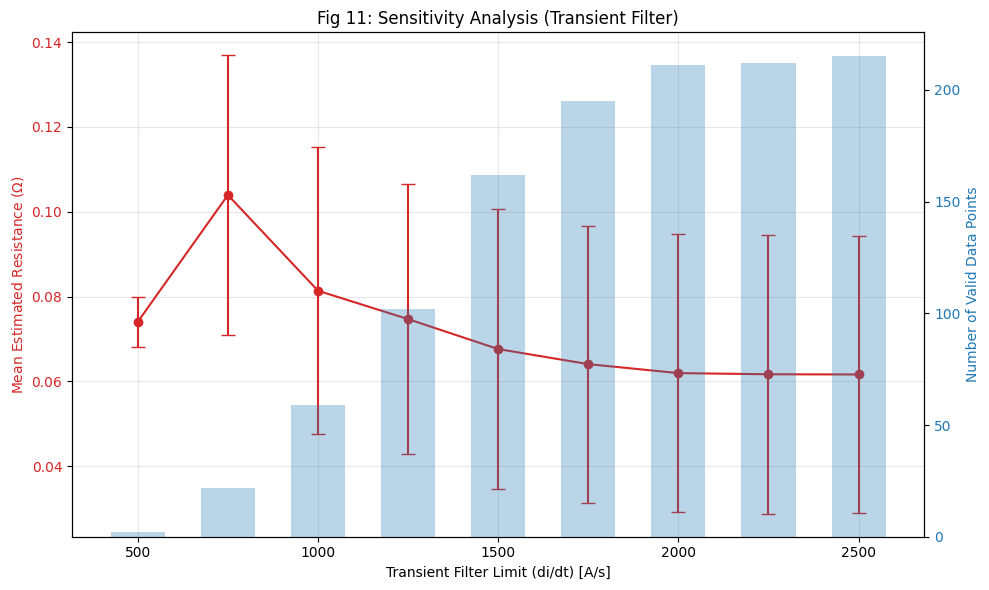

    Saved Data: DATA_FIG11_Sensitivity_Analysis.csv

[-] Phase 3: Running Structure-Adaptive Regression (R_s, psi_pm)...
    Saved Plot: FIG1_Residual_Diagnosis.png
    Saved PDF: FIG1_Residual_Diagnosis.pdf


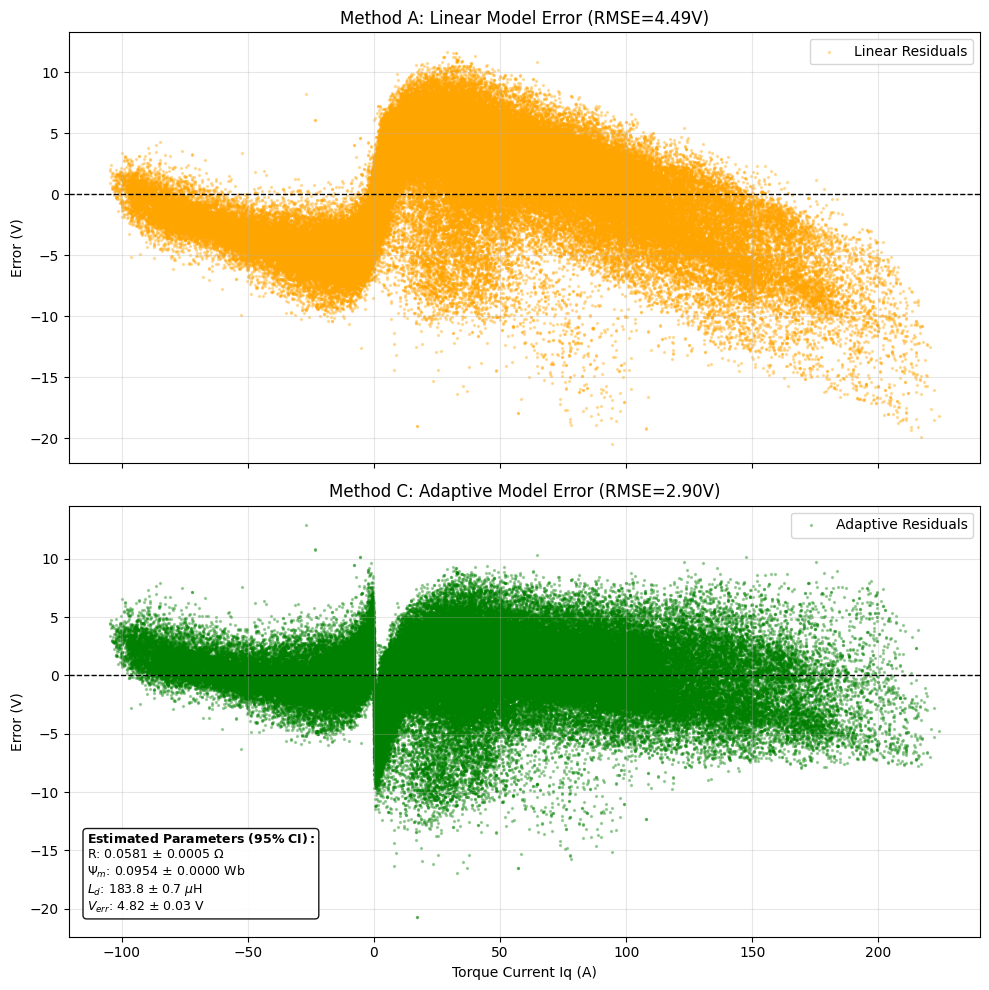

    Saved Data: DATA_FIG1_Residual_Diagnosis.csv
    Saved Plot: FIG12_Parameter_Uncertainty.png
    Saved PDF: FIG12_Parameter_Uncertainty.pdf


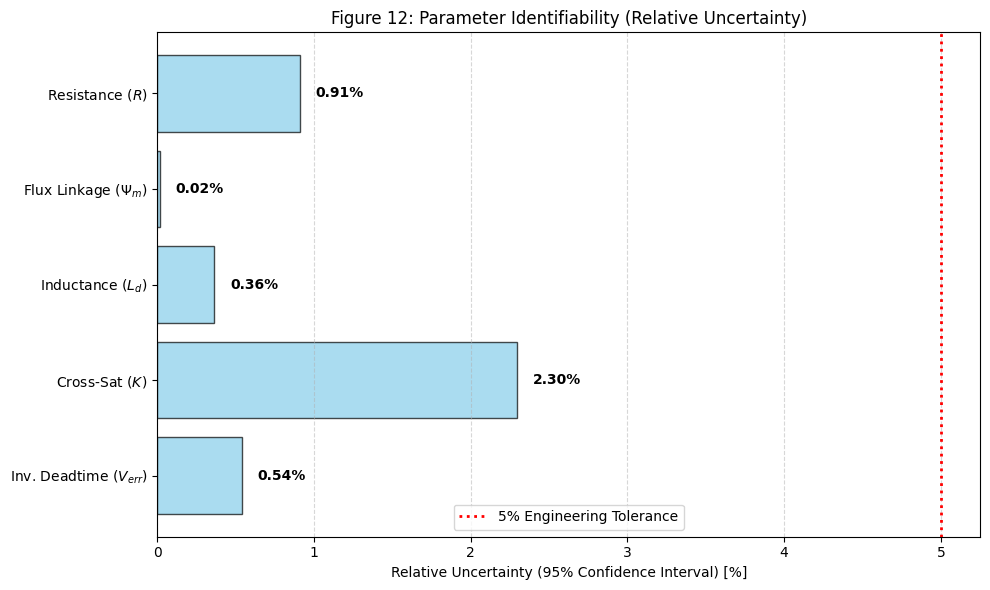

    Saved Data: DATA_FIG12_Parameter_Uncertainty.csv

[-] Phase 4: Generating baseline GPR Flux Surfaces (psi_d, psi_q)...
    Using baseline estimated R_s = 58.107 mOhm
    [Flux Map] Using robust Resistance from Phase 2: 0.0581 Ohm
    [Flux Map] WLTP GPR quadrant filter Id<=0, Iq>=0: 110842 -> 46740 points.
    [GPR] Reduced dataset from 44886 raw points to 362 centroids for Bayesian training.
    [GPR] Training Gaussian Process for d-axis...
    [GPR] Training Gaussian Process for q-axis...
Learned Length Scale: 3.0093767992981943
    [GPR Grid] Prediction/plot grid enforced: Id = [-81.200, 0.000] A, Iq = [0.000, 218.700] A (30 x 30).
    Saved Plot: FIG3_PM_Flux_Variation.png
    Saved PDF: FIG3_PM_Flux_Variation.pdf


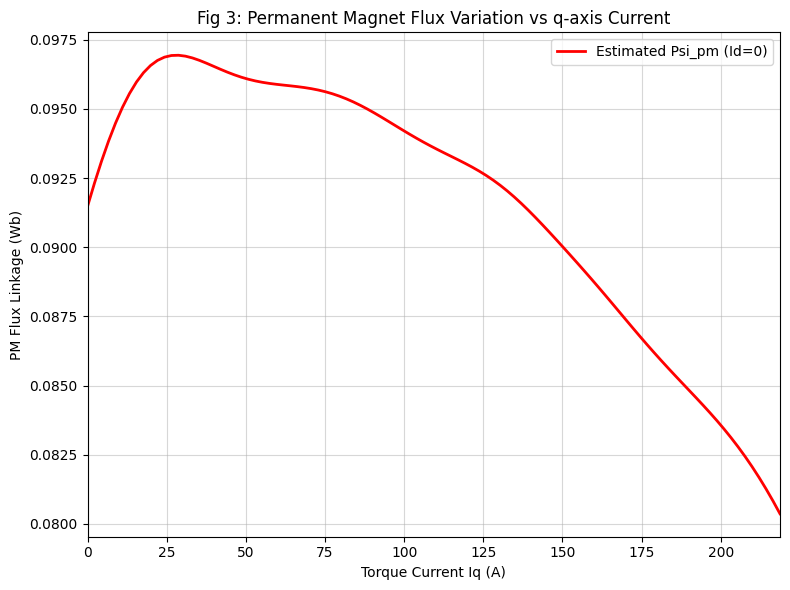

    Saved Data: DATA_FIG3_PM_Flux_Variation.csv

[-] Phase 5a: Computing error metrics vs YASA GPR reference...
    Saved Plot: FIG9_Residual_Histograms.png
    Saved PDF: FIG9_Residual_Histograms.pdf


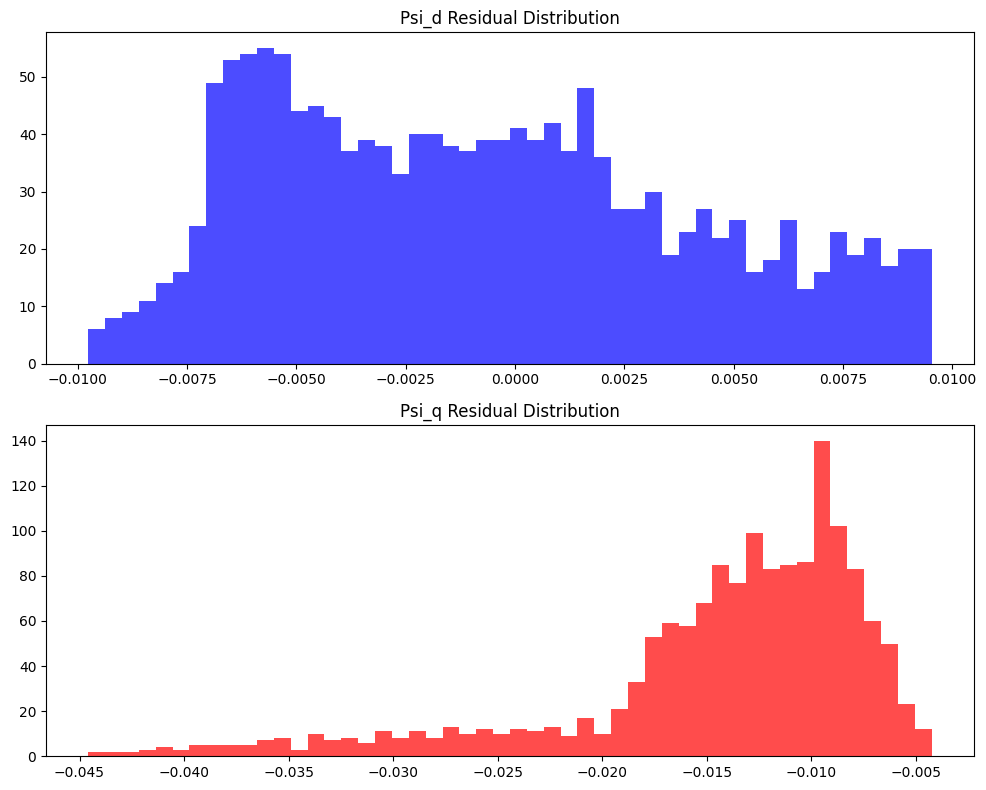

    Saved Plot: FIG5_PM_Flux_Extrapolation.png
    Saved PDF: FIG5_PM_Flux_Extrapolation.pdf


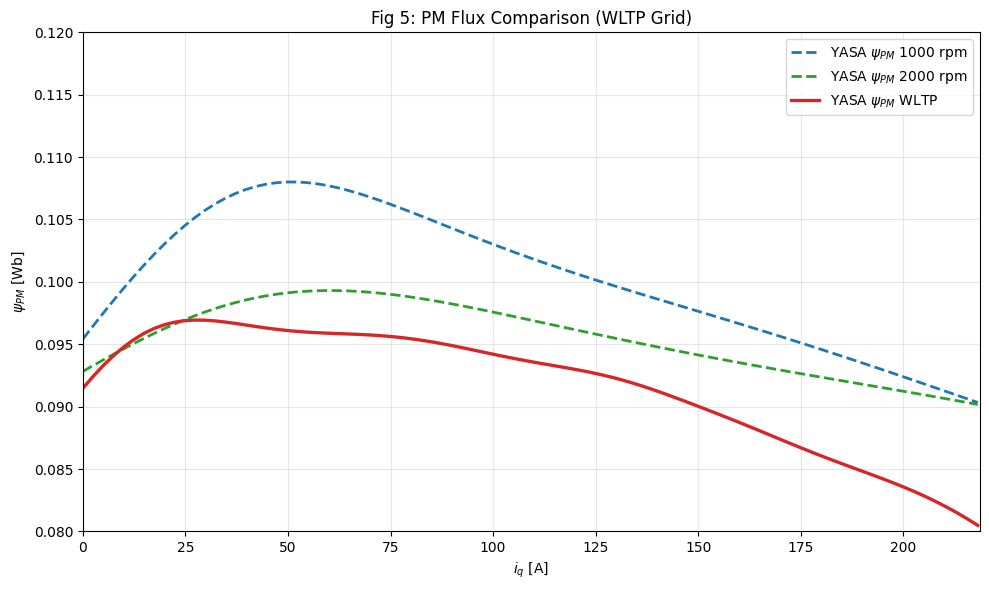

    Saved Data: DATA_FIG5_PM_Flux_Extrapolation.csv
    Saved Plot: FIG8_PM_Error_Analysis.png
    Saved PDF: FIG8_PM_Error_Analysis.pdf


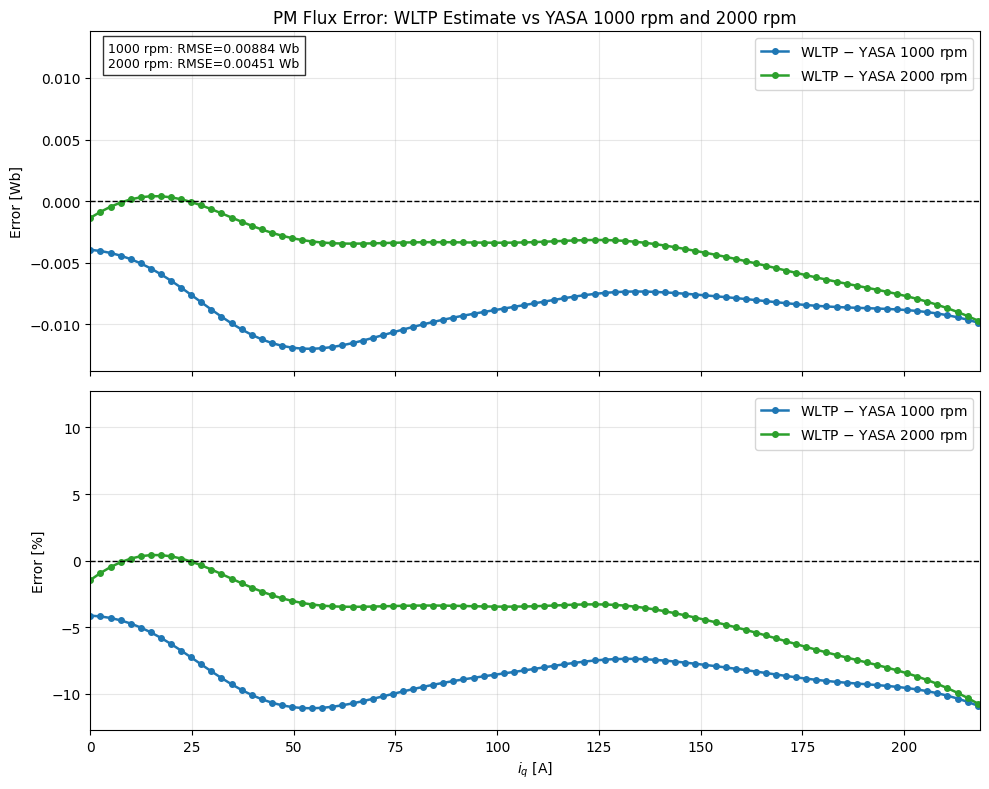

    Saved Data: DATA_FIG8_PM_Error_Analysis.csv

[-] Phase 5b: Running Kernel Sensitivity Analysis...

    [Kernel Sweep] Starting sensitivity analysis...
    [Kernel Sweep] Testing kernels on 144 spatial centroids.
    Kernel: RBF (Baseline)  | Score (LML): 662.08
    Kernel: Matern 5/2      | Score (LML): 664.04
    Kernel: Linear + RBF    | Score (LML): 661.93
    Saved Plot: FIG13_Kernel_Sensitivity.png
    Saved PDF: FIG13_Kernel_Sensitivity.pdf


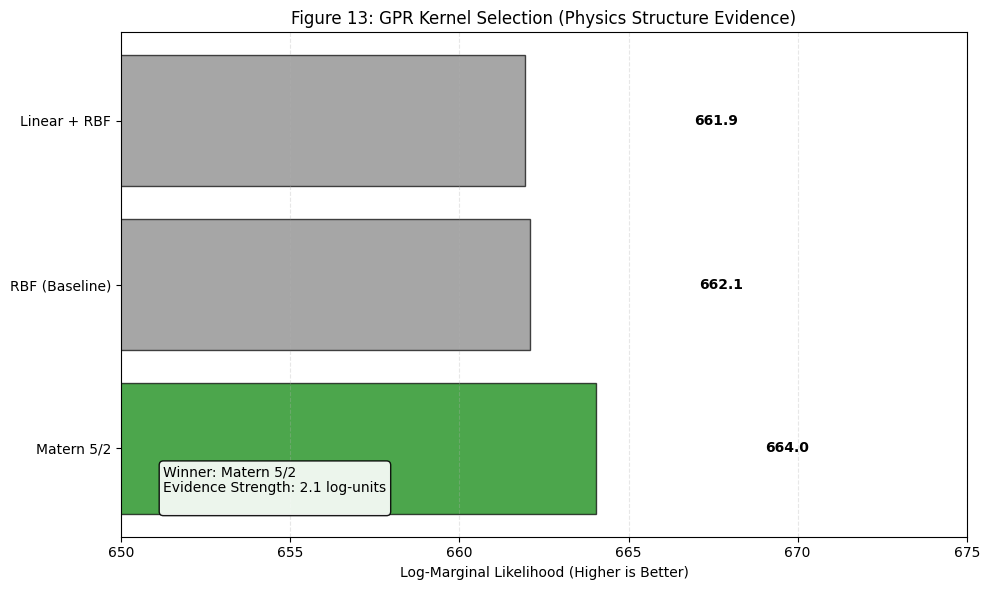

    Saved Data: DATA_FIG13_Kernel_Sensitivity.csv
    Best Kernel Identified: Matern 5/2

[-] Phase 6: Tracking R_s vs time (di/dt limit: 1500.0 A/s)...
    Saved Plot: FIG4_Identifiability_Gap.png
    Saved PDF: FIG4_Identifiability_Gap.pdf


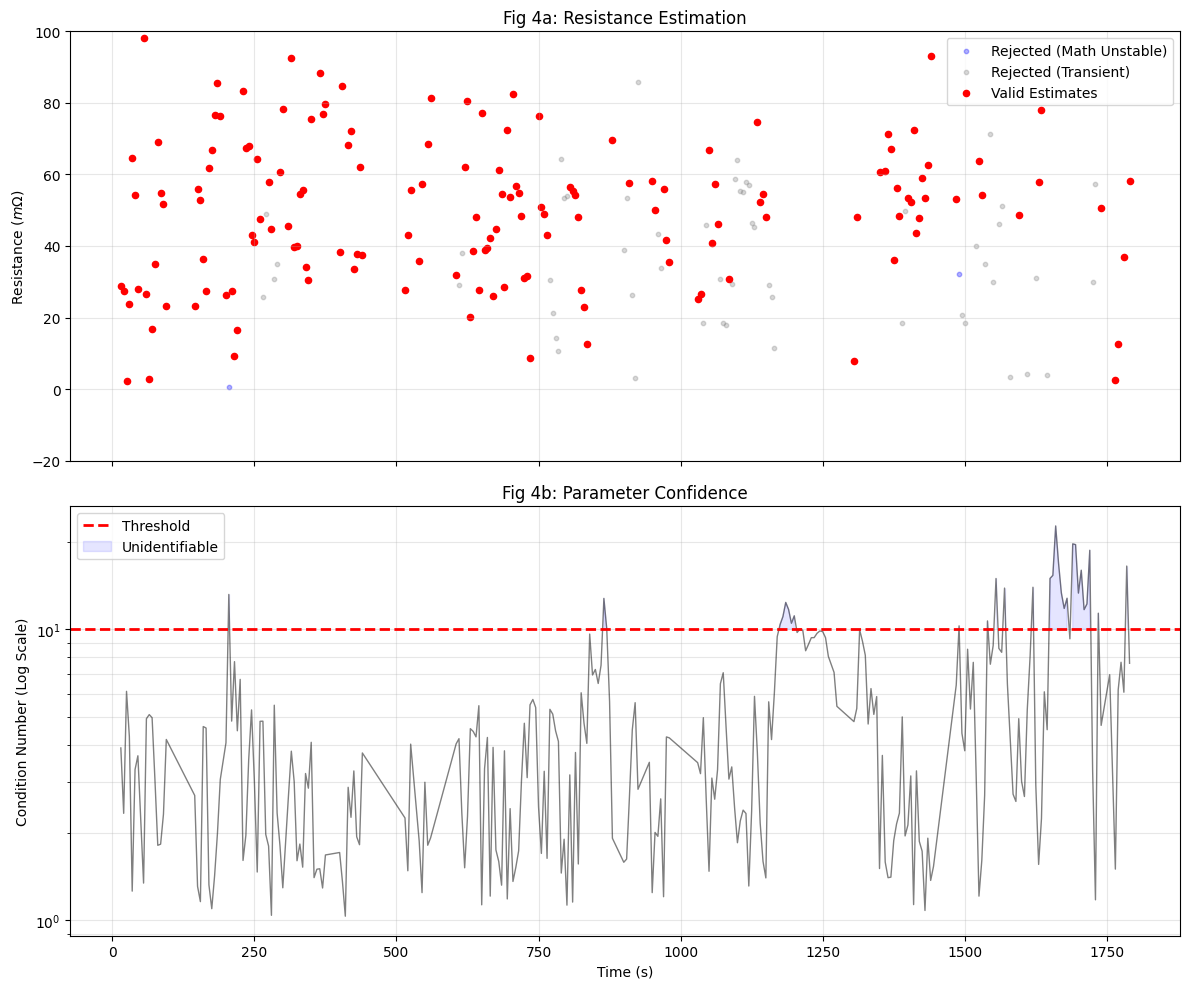

    Saved Data: DATA_FIG4_Identifiability_Gap.csv

[-] Phase 7: Running Speed-Regime Analysis (Iron-loss signature)...
[-] Phase 7: Running Regime Analysis (The 'Novelty')...
    Identifying parameters in 3 speed zones...
    > Low (<2000 rpm)      | R=0.0991, Psi=0.0940
    > Mid (2000-4000 rpm)  | R=0.0923, Psi=0.0961
    > High (>4000 rpm)     | R=-0.0121, Psi=0.0939


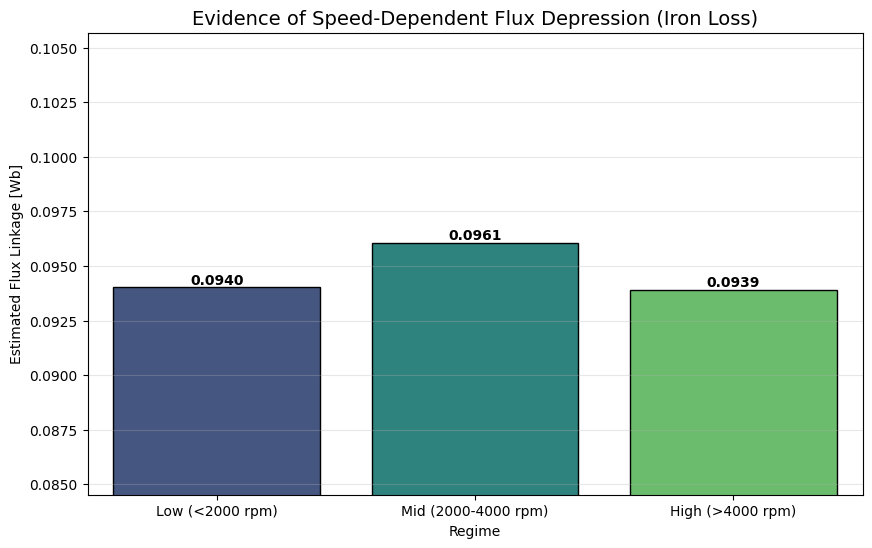

    Saved Novelty Plot: FIG_NOVELTY_Flux_Drift.png


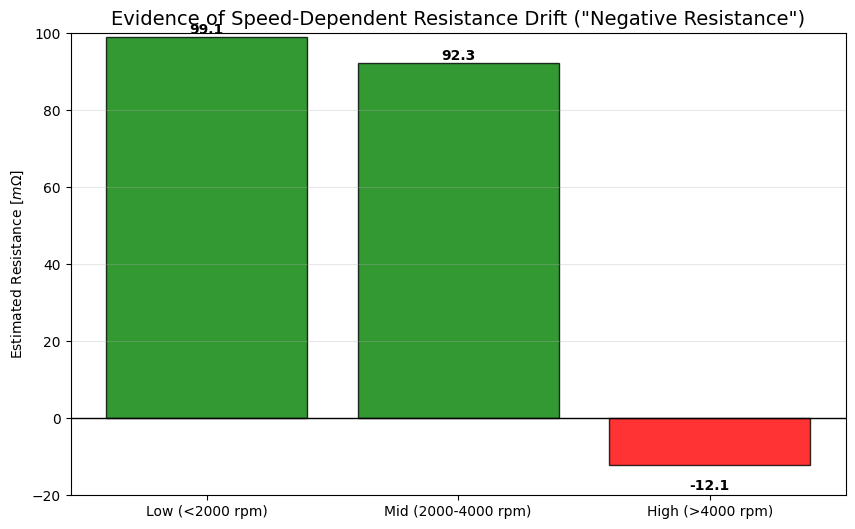

    Saved Novelty Plot: FIG_NOVELTY_Resistance_Drift.png

[-] Phase 8: Running Power-Balance / Iron-Loss Isolation...
[-] Phase 8: Running Energy Balance Analysis (Iron Loss Isolation)...
    [Energy] Using Dynamic Low-Speed Anchor R = 0.0991 Ohm
    Analyzing 110730 stable operating points...


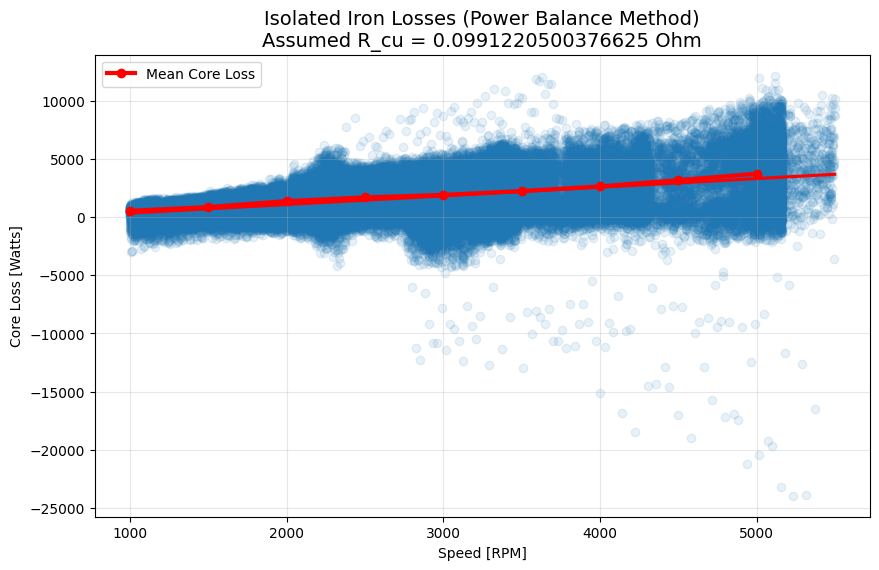

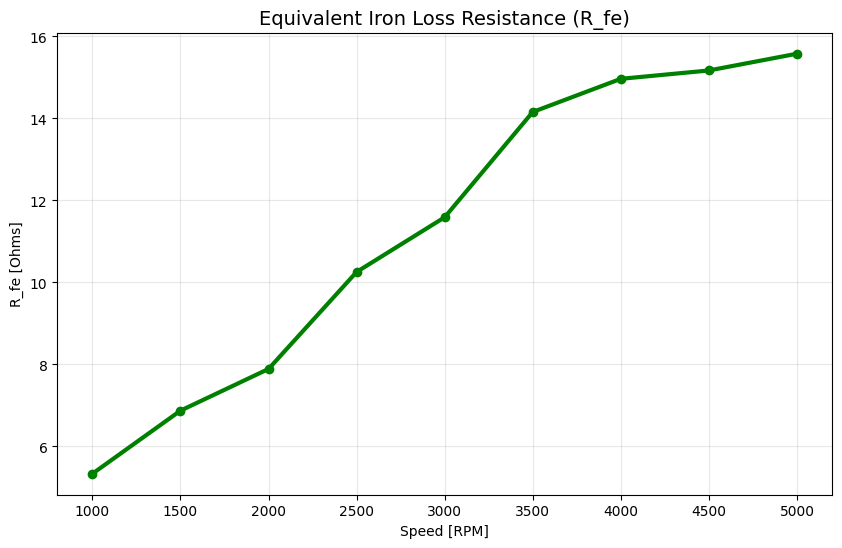

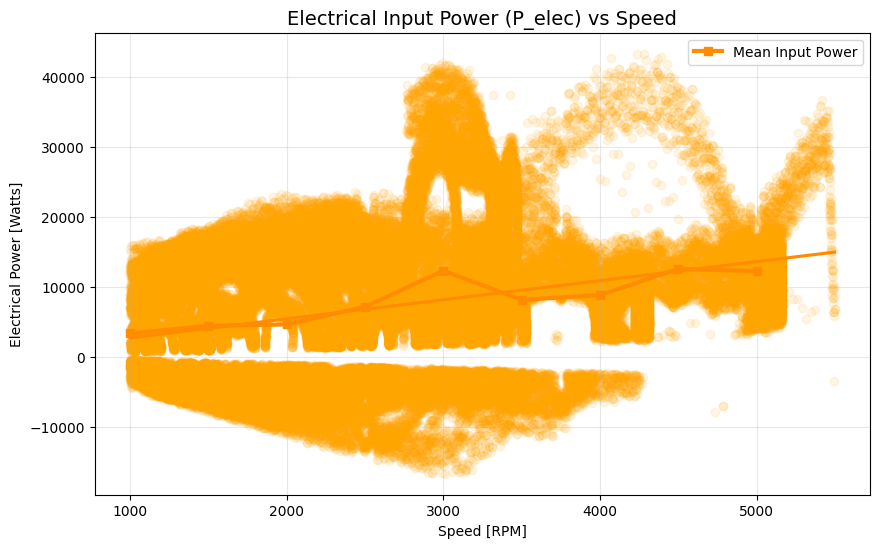

    Saved Power Balance Results.
    This data explains the 'Negative Resistance' phenomenon.

[-] Phase 9: VERIFICATION (Applying Iron-Loss Correction)
    [Correction] Applying Speed-Dependent Iron Loss Model...
    [Correction] Adjusted currents. Max adjustment: 12.94 A
    [Correction] Applying Speed-Dependent Iron Loss Model...
    [Correction] Adjusted currents. Max adjustment: 12.94 A
    [Debug] Time Step Analysis:
            Avg dt: 0.010000 s (Freq: 100.0 Hz)
    [Debug] Derivative (di/dt) Analysis:
            Max Found: 2393.4557 A/s
            99th Pctl: 1320.5689 A/s
            Filter Limit: 1500.0 A/s
    [Filter] Raw Data: 180027 -> High Speed: 150297 -> Stable (di/dt<1500.0): 149544
    Re-running Adaptive Regression on Corrected Data...
    Re-generating GPR flux surfaces from corrected data...
    [Flux Map] Using robust Resistance from Phase 2: 0.0835 Ohm
    [Flux Map] WLTP GPR quadrant filter Id<=0, Iq>=0: 110842 -> 31002 points.
    [GPR] Reduced dataset from 

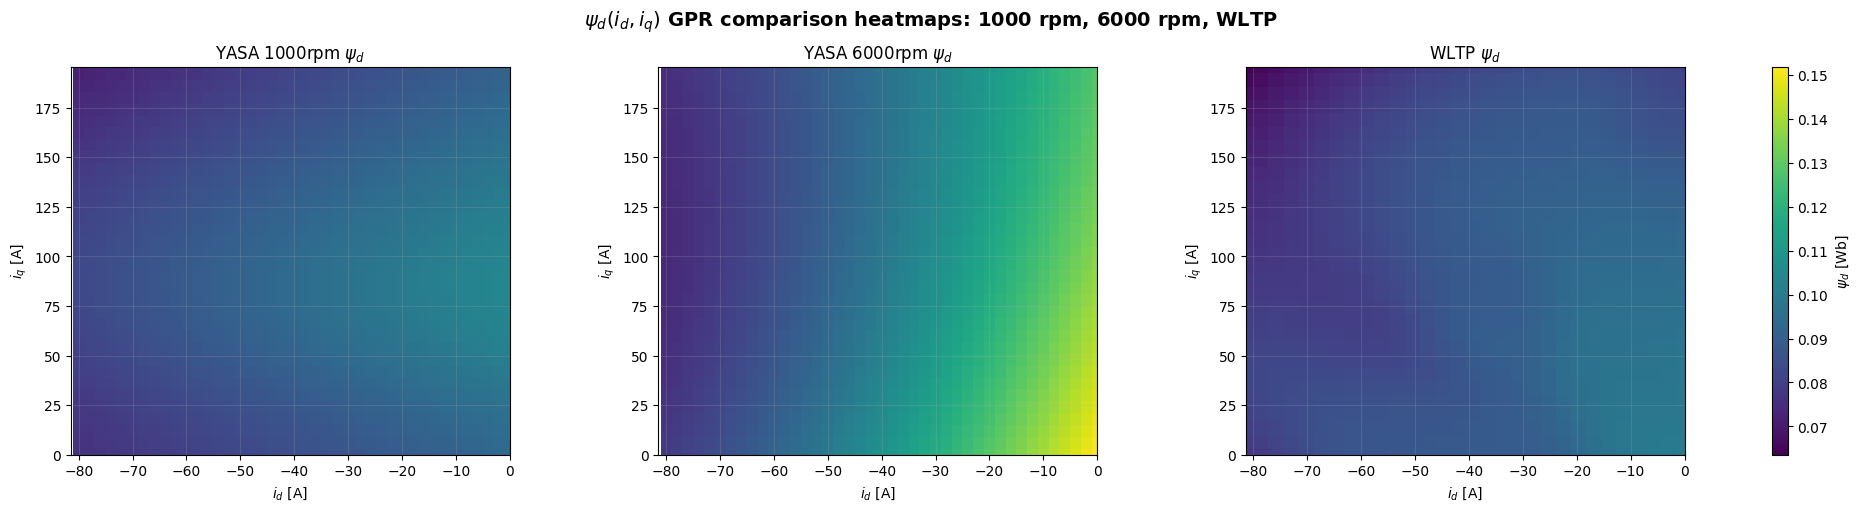

    Saved Data: DATA_FINAL_Psi_d_GPR_Heatmaps_CORRECTED.csv
    Saved Plot: FINAL_Psi_d_Error_Heatmaps_CORRECTED.png
    Saved PDF: FINAL_Psi_d_Error_Heatmaps_CORRECTED.pdf


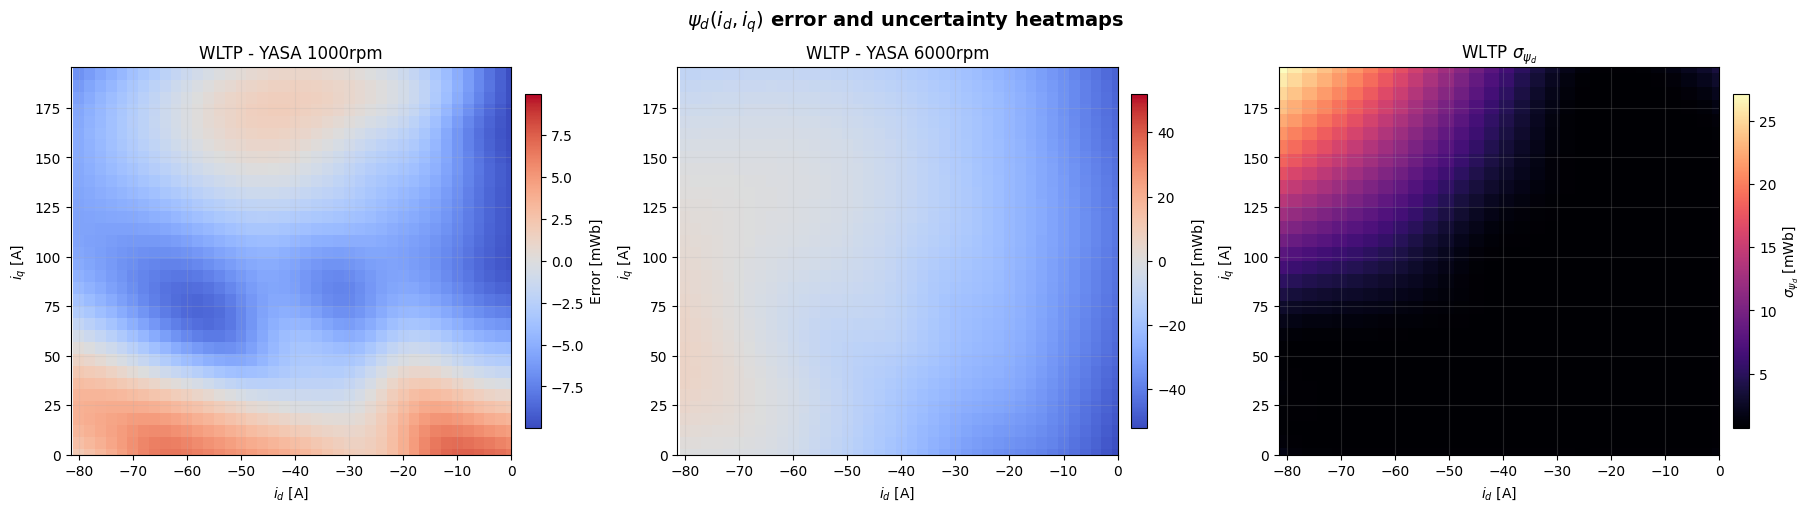

    Saved Data: DATA_FINAL_Psi_d_Error_Heatmaps_CORRECTED.csv
    Saved Plot: FINAL_Psi_q_GPR_Heatmaps_CORRECTED.png
    Saved PDF: FINAL_Psi_q_GPR_Heatmaps_CORRECTED.pdf


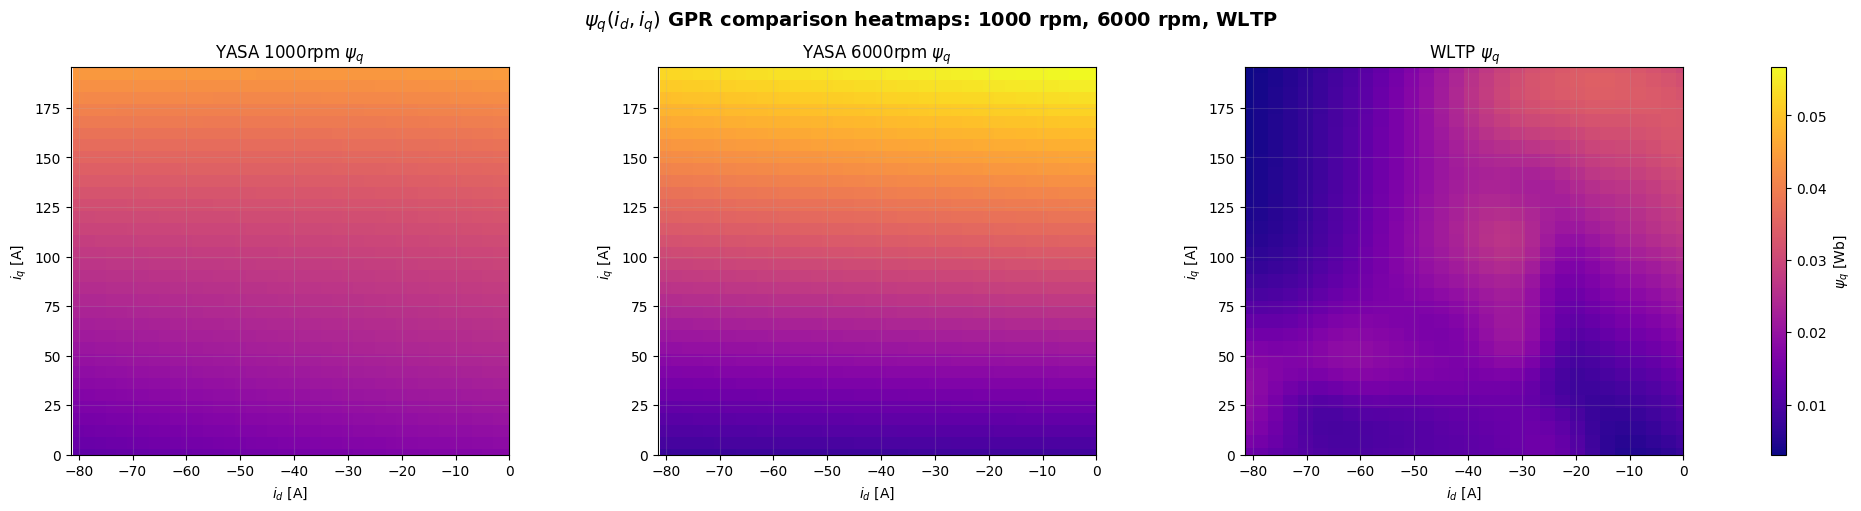

    Saved Data: DATA_FINAL_Psi_q_GPR_Heatmaps_CORRECTED.csv
    Saved Plot: FINAL_Psi_q_Error_Heatmaps_CORRECTED.png
    Saved PDF: FINAL_Psi_q_Error_Heatmaps_CORRECTED.pdf


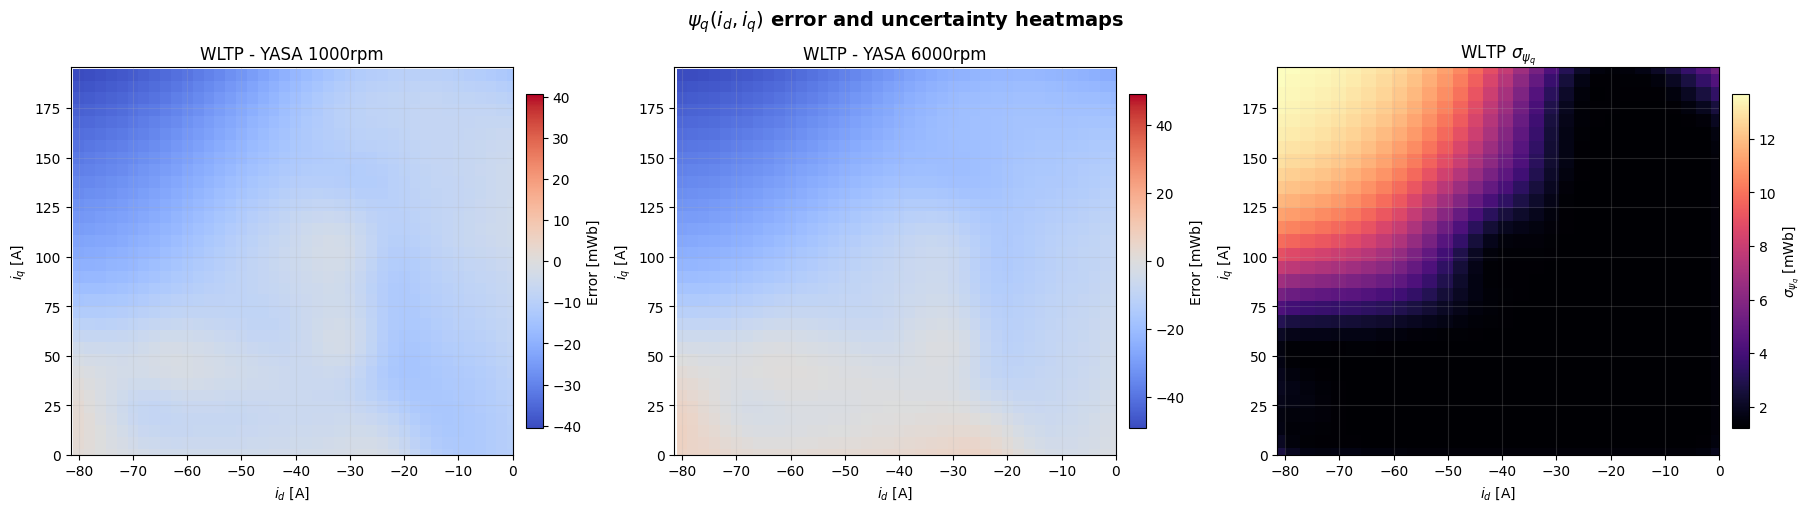

    Saved Data: DATA_FINAL_Psi_q_Error_Heatmaps_CORRECTED.csv
    Saved Plot: FINAL_WLTP_Psi_dq_Surfaces_CORRECTED.png
    Saved PDF: FINAL_WLTP_Psi_dq_Surfaces_CORRECTED.pdf


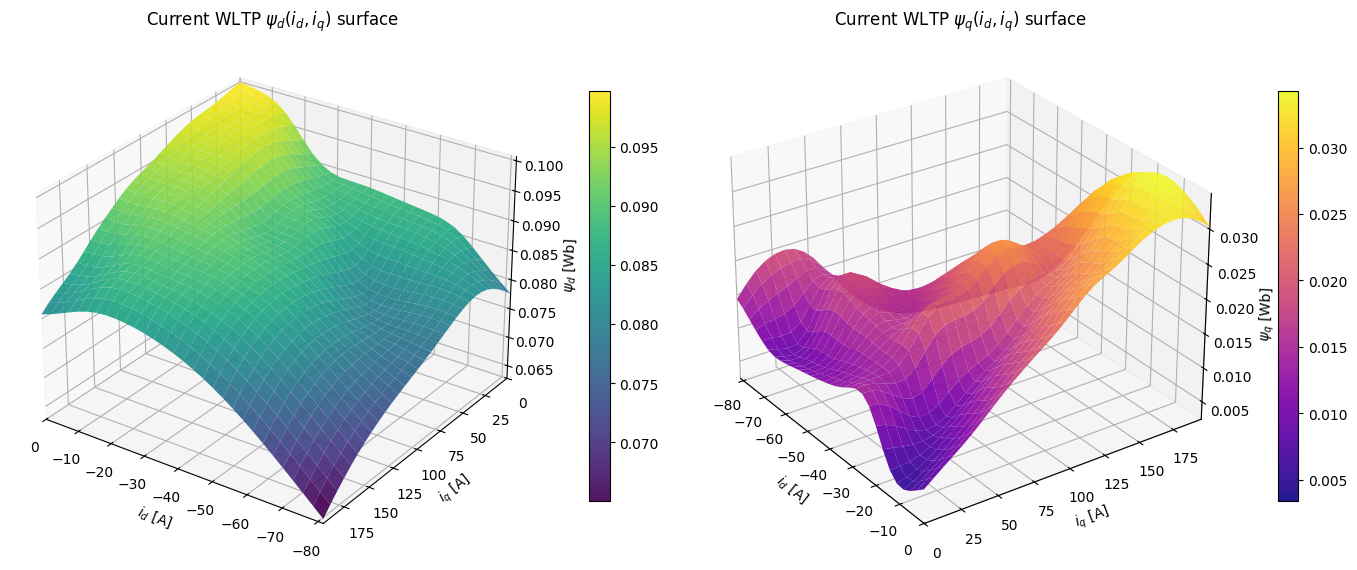

    Saved Data: DATA_FINAL_WLTP_Psi_dq_Surfaces_CORRECTED.csv
    Saved Plot: FINAL_Psi_dq_CI_Slices_CORRECTED.png
    Saved PDF: FINAL_Psi_dq_CI_Slices_CORRECTED.pdf


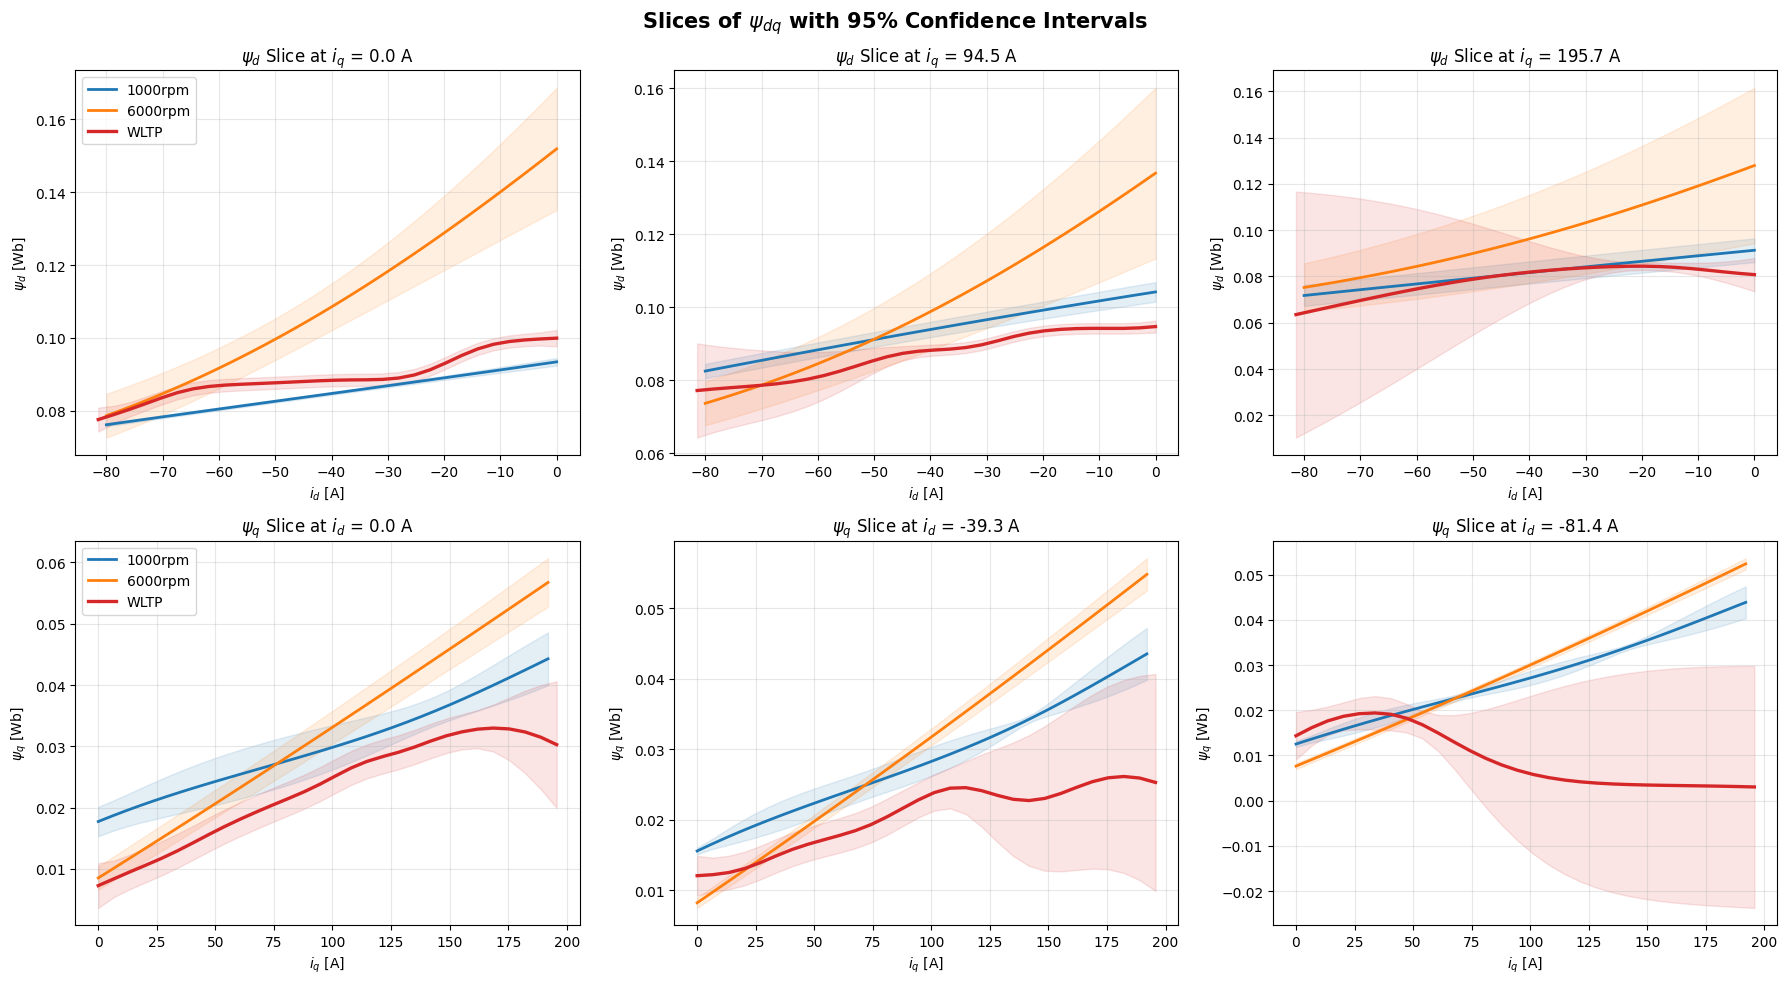

    Saved Data: DATA_FINAL_Psi_dq_CI_Slices_CORRECTED.csv

 FINAL ESTIMATION REPORT (with 95% Confidence)
  Stator Resistance (R_s):       83.49 ±  0.59  mOhm
  PM Flux Linkage (psi_pm):      98.05 ±  0.02  mWb (regression coef.)
  Inverter Deadtime (V_err):    2.0517 ± 0.0304  V
  (Reg. Ld coefficient kept internally for unbiased R/psi -- not exported)
------------------------------------------------------------

  Flux surface error vs YASA GPR reference:
     psi_d : MAE =   4.01 mWb  RMSE =   4.72 mWb  max =   9.96 mWb  (n = 1353)
     psi_q : MAE =  11.42 mWb  RMSE =  14.01 mWb  max =  40.50 mWb  (n = 1353)
     psi_pm: MAE =   4.36 mWb  RMSE =   5.15 mWb  max =  10.40 mWb  (n = 79)

[-] Pipeline Complete. All results saved to:
    C:\Users\cbbw20\OneDrive - University of Bath\Desktop\University\AAPS CDT\PhD\Modelling\python\yasa\final_est_pipelines\p400s_wltp_raw_RUN_2026-05-11_21-34-21


In [9]:
pipeline_results = main()
